In [1]:
# using Pkg

# Pkg.build("PyCall")

In [1]:
# loading modules
using PyPlot, Printf, LinearAlgebra, FFTW, FileIO, JLD2

using CUDA

using Setfield

# include("../../LinStab/mjcl_stab.jl")
# using .LinStab

using FourierFlows: CPU, TwoDGrid, plan_flows_rfft

using GeophysicalFlows

using Glob

using Statistics

using Parameters

using StaticArrays, KernelAbstractions

using LoopVectorization, Base.Threads


run_file_dir = "/scratch/cimes/ml1994/QG/julia/QG_topo/"
include(run_file_dir * "mjcl_gfjl_fcns.jl")


update_two_layer_omega_diags (generic function with 2 methods)

# Defining model parameters

In [2]:

dev = GeophysicalFlows.CPU()

Ny = Nx = n = 1024                # 2D resolution = n²


###################################################################################
## Geometry and background fields
###################################################################################

Nz = nlayers = 2                 # number of layers
f0 = f₀= 8.3e-5            # Coriolis param [s^-1]
g = 9.81                    # gravity
H = [2000., 2000.]     # the rest depths of each layer;

Us = [0.01, 0.017634058790440166, 0.024]
rhos = 1025.75 - 0.5775

kt = 0.

rho0 = 1025.        # Boussinesq reference density

# always zero for now, model can't even take this in as a parameter...
V = zeros(nlayers)


# running model

rho = ρ = [0., 1025.75]
rho[1] = ρ[1] = rhos[1]

strat_str = "uni_strat"
shear_str = "uni_shear"

# change U here
U = [0.,0.]
U[1] = Us[1]

gprime = (g/rho0)*(ρ[2] - ρ[1])

Ld = sqrt(gprime * sum(H)) / 2 / f0

L = Lx = Ly = 25*2*pi*Ld   # domain size [m]

###################################################################################
## Planetary PV gradient
###################################################################################
betas = βs = collect(range(-1.5,1.5,13)) * (U[1]/2) * Ld^-2
β = 0. # 1e-11              # the y-gradient of planetary PV; beta = β = 0. * (U[1]/2) * Ld^-2

###################################################################################
## Topography
###################################################################################

# set topography w/ current options:
topo_type = "y_slope"

# Defining a bulk slope parameter...should probably change this!

# setting slope(s)
S32 = f0 * U[1] / gprime

dyetab_over_S32 = collect(range(-1.5,1.5,13))
h0s = dyetab_over_S32 .* S32
# h0s = h0s[7:end]

# tuple of (bottom slope, h_rms)
h0 = (h0s[1], 0.)    #

# central wavenumber for rough topo
kt = 0.

# defining GFJL topo params
interim_params = mod_params(topo_type=topo_type, h0=h0, kt=kt)

topographic_pv_gradient, eta = define_topo(interim_params)

###################################################################################
# Dissipation
###################################################################################

# biharmonic viscosity
nν = 4
νstar = 10^-11 # 10^-13
ν = νstar * ((U[1]-U[end])/2) * (Lx/2/pi)^7

dyn_nu = false

# Linear bottom drag
μstars = [0.125, 0.25, 0.5, 1.0, 2.0, 4.0]
mus = @. μstars * ((U[1]-U[end]) / 2) / Ld

# Quadratic bottom drag
κstars = [0.]
kappas = [0.] # @. κstars / Ld

###################################################################################
## Time stepping and sample rate
###################################################################################

if ν==0.
    stepper = "FilteredETDRK4"
    # af = 0.
    # global filt_order=4
    # global innerK = 2/3
else
    stepper = "ETDRK4"
    # af = 1/3
    # global filt_order=4
    # innerK = 2/3
end

# should I set dt via CFL condition instead?
dt = 600.

###################################################################################
## Details of saving data
###################################################################################
global diags = diag_bools(two_layer_kspace_modal_nrg_budget_bool=true);

# where to save model output; frequency of output
data_dir = "/scratch/cimes/ml1994/QG/julia/data/sloping_LD_two_layer_data/"

alt_data_dir = "/scratch/cimes/ml1994/QG/julia/data/JFM_May2025_data/"

f_s = 5. * (Ld / ((U[1]-U[end])/2)) #  N eddy turnover periods

# sampling period in time steps (set above)
nsubs = round(Int64, f_s/dt)

###################################################################################
## Model run parameters
###################################################################################

# steady-state  parameters
ss_yr_max = ceil(100 * (Ld / ((U[1]-U[end])/2)) / 3600 / 24 / 365.25)  # number of eddy periods converted to years for model run
yr_increment = 1.0 # how often to write to a save file

restart_bool = false

pre_buoy_restart_file = true
data_dir_pre_buoy = "/scratch/cimes/ml1994/QG/julia/data/two_layer_drag_study/"
data_dir_2L = "/scratch/cimes/ml1994/QG/julia/data/sloping_2L_hi_output_WFS/"

###################################################################################
## Define params struct
###################################################################################
global model_params = mod_params(
data_dir = data_dir,
Nz = Nz, Nx = Nx, Ny = Ny, Lx = Lx, Ly = Ly, Ld = Ld,
H = H,
rho0 = rho0, rho = rho, strat_str = strat_str,
shear_str = shear_str, U = U,
μ = mus[1], κ = kappas[1], nν = nν, ν = ν, dyn_nu = dyn_nu,
eta = eta, topographic_pv_gradient = topographic_pv_gradient, topo_type = topo_type, h0 = h0,
f0=f0, β = β,
dt = dt,
stepper = stepper,
dev = dev,
restart_bool = restart_bool,
pre_buoy_restart_file = pre_buoy_restart_file,
data_dir_pre_buoy = data_dir_pre_buoy,
ss_yr_max = ss_yr_max,
yr_increment = yr_increment,
nsubs = nsubs)

###################################################################################
## Initialize model
###################################################################################

prob, prob_filt = initialize_model(model_params);

# prob = set_initial_conditions(prob, prob_filt, model_params)

sol, clock, params, vars, grid = prob.sol, prob.clock, prob.params, prob.vars, prob.grid;




In [3]:
dev = grid.device
T = eltype(grid)
A = device_array(dev)

rfftplan = plan_flows_rfft(A{T, 3}(undef, grid.nx, grid.ny, 1), [1, 2]; flags=FFTW.MEASURE);


In [4]:
function redef_mu_kappa(model_params, mu, kappa)
    @unpack_mod_params model_params

    mp_out = mod_params(
    data_dir = data_dir,
    Nz = Nz, Nx = Nx, Ny = Ny, Lx = Lx, Ly = Ly, Ld = Ld,
    H = H,
    rho0 = rho0, rho = rho, strat_str = strat_str,
    shear_str = shear_str, U = U,
    μ = mu , κ = kappa , nν = nν, ν = ν, dyn_nu=dyn_nu,
    eta = eta, topographic_pv_gradient = topographic_pv_gradient, topo_type = topo_type, h0 = h0,
    β = β,
    dt = dt,
    stepper = stepper,
    dev = dev,
    restart_bool = restart_bool,
    ss_yr_max = ss_yr_max,
    yr_increment = yr_increment,
    nsubs = nsubs);

    return mp_out
end

redef_mu_kappa (generic function with 1 method)

In [5]:
using PlotUtils

cm = cgrad(:coolwarm);
clrs = [cm[i] for i in range(0,1,100)]

hc_range = collect(range(h0s[1],h0s[end],100))

function h_color(h_in,hc_range,colors)
    c_ind = argmin(abs.(h_in .- (hc_range)))

    color_out = [red(clrs[c_ind]),green(clrs[c_ind]),blue(clrs[c_ind])]

    if h_in==0
        color_out = [0.,0.,0.]
    end
    return color_out
end

####################################################################
## 
####################################################################

function plot_info_box(ax, var, x, y, plus_mode, fsize)
    textstr = var * "\n" * L"+ \rightarrow" * plus_mode

    # these are matplotlib.patch.Patch properties
    props = Dict("boxstyle"=>"round", "facecolor"=>"wheat", "alpha"=>0.5)
    
    # place a text box in upper left in axes coords
    ax.text(x, y, textstr, transform=ax.transAxes, fontsize=fsize,
            ha="left", va="top", bbox=props)

    return nothing
end


####################################################################
## 
####################################################################


# tab20_range = collect(range(0,1,20))

function tab20_color(c_ind)

    cm2 = cgrad(:tab20);
    clrs2 = [cm2[i] for i in range(0,1,20)]

    color_out = [red(clrs2[c_ind]),green(clrs2[c_ind]),blue(clrs2[c_ind])]

    return color_out
end



tab20_color (generic function with 1 method)

In [6]:

function redef_mu_kappa_topoPV_h0(model_params, mu, kappa, topo_PV, h0_new)
    @unpack_mod_params model_params

    mp_out = mod_params(
    data_dir = data_dir,
    Nz = Nz, Nx = Nx, Ny = Ny, Lx = Lx, Ly = Ly, Ld = Ld,
    H = H,
    rho0 = rho0, rho = rho, strat_str = strat_str,
    rhotop = rhotop, rhobottom = rhobottom, rhoscaledepth = rhoscaledepth,
    shear_str = shear_str, U = U,
    Utop = Utop, Ubottom = Ubottom, Uscaledepth = Uscaledepth,
    μ = mu , κ = kappa , nν = nν, ν = ν, dyn_nu=dyn_nu, dyn_nu_coeff=dyn_nu_coeff,
    eta = eta, topographic_pv_gradient = topo_PV, topo_type = topo_type, h0 = h0_new, kt=kt,
    f0 = f0, β = β,
    dt = dt,
    stepper = stepper,
    dev = dev,
    restart_bool = restart_bool,
    restart_yr = restart_yr,
    pre_buoy_restart_file = pre_buoy_restart_file,
    data_dir_pre_buoy = data_dir_pre_buoy,
    pre_multilayer_restart_file = pre_multilayer_restart_file,
    pre_multilayer_dir = pre_multilayer_dir,
    ss_yr_max = ss_yr_max,
    yr_increment = yr_increment,
    nsubs = nsubs);

    return mp_out
end

redef_mu_kappa_topoPV_h0 (generic function with 1 method)

# Modes of variability stuff...looking to isolate BC and BT waves

In [7]:
# wavenumber-frequency spectra
# νstars = [10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11 , 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11]
νstars = [10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11, 10^-11 , 10^-13, 10^-13, 10^-13, 10^-13, 10^-13, 10^-13]

nus = νstars .* ((U[1]-U[end])/2) * (Lx/2/pi)^7
ν = nus[1]

i=6  # bottom slope index
j=1  # quad drag index
k=2  # linear drag index


h0 = (h0s[i], 0.0)
kappa_loc = kappas[j]
mu_loc = mus[k]

global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, (0., 0.), h0, nus[i])
global topo_PV, eta = define_topo(model_params)
global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, topo_PV, h0, nus[i])

global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, 0.)

# filename = "/layer2_Htot_4000.0_L_2pi4.449E+06_y_slope_h0_-2.253E-04_beta0.000E+00_uni_shear_uni_strat_mu1.765E-07_kappa0.000E+00_nu0.000E+00_res1024_yr62.95.jld"

# added 2pi added tot
# data_dir_hi_budget = "/scratch/cimes/ml1994/QG/julia/data/sloping_2L_2D_budget_hi_output/"
# a = load(data_dir_hi_budget*jld_name(model_params,84.95))

data_dir_psi_ot = "/scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu0p25_hov/"

a = load(data_dir_psi_ot*jld_name(model_params,89.5))

# a = load(data_dir*filename)


# energies are: (1) BTEKE, (2) BCEKE, (3) EAPE; (4) CBC; (5) Tflat, (6) Ttopo; , (7) DBT, (8) DBC;
#               (9) NLBC2BT, (10) NLBTEKE, (11) NLBT2BC; (12) NLBVEKE (13) NLBCEAPE (14) resid

# layer2_Htot_4000.0_L_2pi4.449E+06_y_slope_h0_0.000E+00_beta3.116E-12_uni_shear_uni_strat_mu8.826E-08_kappa0.000E+00_nu0.000E+00_res1024_yr57.7.jld

# layer2_H_4000.0_L_4.449E+06_y_slope_h0_3.754E-05_beta0.000E+00_uni_shear1.000E+000.000E+001.000E+03
# _uni_strat1.025E+031.026E+031.000E+03__mu4.413E-08_kappa0.000E+00_nu4.464E+27_res1024_yr89.5.jld


# readdir(data_dir_psi_ot)



Dict{String, Any} with 1 entry:
  "jld_data" => Dict{String, Array{Float64}}("t"=>[1.38853e9, 1.38854e9, 1.3894…

# A plot on the arrest scale

Here is what I need to have a figure on arrest scale:

- Define two rms velocities: zonal mean and total (BOTH BAROTROPIC)
- Define dispersion relation (constant U=0.01 for now)
- Define a function that takes in urms and phase speed and spits out a length scale
- Define length scales of flow (i.e., energy maximum, energy centroid, energy-containing wavenumber)
- Plot, as a function of bottom slope, these length scales (two panels for two friction values)
- Make sure to include Rhines scale

In [11]:

function rmsU(h_ind, mu_ind, data_dir, model_params, first_yr, last_yr)
    i = h_ind
    k = mu_ind  
    
    h0 = (h0s[i], 0.0)
    kappa_loc = 0.0
    mu_loc = mus[k]
    
    global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, (0., 0.), h0, nus[i])
    global topo_PV, eta = define_topo(model_params)
    global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, topo_PV, h0, nus[i])
    
    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, 0.)

            
    Nx, Ny = grid.nx, grid.ny


    # Only plan once
    # rfftplan = plan_flows_rfft(A{T,2}(undef, Nx, Ny), [1,2]; flags=FFTW.MEASURE)
    rfftplan = plan_rfft(randn(Nx, Ny); flags=FFTW.MEASURE)
    
    years = collect(range(first_yr, last_yr, step=0.5))
    nyears = length(years)
    
    # Preallocate buffers
    # ψ2h = similar(vars.ψh[:,:,2])
    # ζ2h = similar(ψ2h)
    # ζ2 = similar(vars.ψ[:,:,2])
    
    ψ1h = similar(vars.ψh[:,:,2])
    ψ2h = similar(vars.ψh[:,:,2])
    ζ1h = similar(ψ1h)
    ζ1 = similar(vars.ψ[:,:,2])
    
    v1h = similar(ψ1h)
    v1 = similar(ζ1)

    u1h = similar(ψ1h)
    u1 = similar(ζ1)

    v2h = similar(ψ1h)
    v2 = similar(ζ1)

    u2h = similar(ψ1h)
    u2 = similar(ζ1)
    # v2h = similar(ψ2h)
    # v2 = similar(vars.ψ[:,:,2])

    u1zm = zeros(1,Ny)
    v1zm = similar(u1zm)
    u2zm = similar(u1zm)
    v2zm = similar(u1zm)
    

    # Instead of concatenating (which reallocates), store in preallocated arrays
    nt_per_year =  size(load(data_dir*jld_name(model_params, years[1]))["jld_data"]["psi_ot"], 4)
    nt_total = nyears * nt_per_year

    # ubar_yt = Array{Float64}(undef, Ny, 2*nt_total)
    # tau_xyt = Array{Float64}(undef, Nx, Ny, nt_total)

    ψ2_slice = similar(v1)
    ψ1_slice = similar(v1)
    
        # -------------------
    u_zonal_rms = 0.0
    u_total_rms = 0.0
    u_pert_rms = 0.0
    v_total_rms = 0.0
    ec_zonal_scale = 0.0
    
    is = 0
    for yi in eachindex(years)
        yr = years[yi]
        println(yr)
        a = load(data_dir * jld_name(model_params, yr))
        ψ1 = a["jld_data"]["psi_ot"][:,:,1,:]
        ψ2 = a["jld_data"]["psi_ot"][:,:,2,:]
    
        for it in 1:(size(ψ1)[3])
            is+=1

            ψ2_slice = ψ2[:,:,it] # .- mean(ψ2[:,:,it], dims=1)
            ψ1_slice = ψ1[:,:,it] # .- mean(ψ1[:,:,it], dims=1)
    
            # Compute ψBC and store
            # psi_BC_xyt[:,:,is] .= 0.5 * (ψ1_slice .- ψ2_slice) # .- mean(0.5 * (ψ1_slice .- ψ2_slice), dims=1)
    
            # 
            mul!(ψ1h, rfftplan, ψ1_slice)
            @. v1h = im * grid.kr * ψ1h
            ldiv!(v1, rfftplan, v1h)

            @. u1h = -im * grid.l * ψ1h
            ldiv!(u1, rfftplan, u1h)


            mul!(ψ2h, rfftplan, ψ2_slice)
            @. v2h = im * grid.kr * ψ2h
            ldiv!(v2, rfftplan, v2h)

            @. u2h = -im * grid.l * ψ2h
            ldiv!(u2, rfftplan, u2h)

            # u1 .-= mean(u1, dims=1)
            # v1 .-= mean(v1, dims=1)
            # u2 .-= mean(u2, dims=1)
            # v2 .-= mean(v2, dims=1)
            

            u1zm .= mean(u1, dims=1)
            v1zm .= mean(v1, dims=1)
            u2zm .= mean(u2, dims=1)
            v2zm .= mean(v2, dims=1)

            
            u_zonal_rms += sqrt(mean((u1zm.+u2zm).^2 .+ (v1zm.+v2zm).^2))

            u_total_rms += sqrt(mean((u1.+u2).^2 .+ (v1.+v2).^2))

            u_pert_rms += sqrt(mean(((u1 .- u1zm) .+ (u2 .- u2zm)).^2 .+ (v1.+v2).^2))
            
            v_total_rms += sqrt(mean((v1 .+ v2).^2))

            ec_zonal_scale += sqrt(mean((u1zm.+u2zm).^2 .+ (v1zm.+v2zm).^2) ./ mean((mean(ψ1_slice, dims=1) .+ mean(ψ2_slice, dims=1)).^2))

        end

    end
    
    return u_zonal_rms / is, u_total_rms / is, u_pert_rms / is, v_total_rms / is, (ec_zonal_scale / is)^-1
end


rmsU (generic function with 1 method)

In [12]:

data_dir_hov = "/scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu0p25_hov/"


first_yr = 90.5
last_yr = 157.5

u_zonal_rms_mu0p25_h0p25, u_total_rms_mu0p25_h0p25, u_pert_rms_mu0p25_h0p25, v_total_rms_mu0p25_h0p25, ec_scale_mu0p25_h0p25 = rmsU(8, 2, data_dir_hov, model_params, first_yr, last_yr)

u_zonal_rms_mu0p25_h0p75, u_total_rms_mu0p25_h0p75, u_pert_rms_mu0p25_h0p75, v_total_rms_mu0p25_h0p75, ec_scale_mu0p25_h0p75 = rmsU(10, 2, data_dir_hov, model_params, first_yr, last_yr)

u_zonal_rms_mu0p25_h1p25, u_total_rms_mu0p25_h1p25, u_pert_rms_mu0p25_h1p25, v_total_rms_mu0p25_h1p25, ec_scale_mu0p25_h1p25 = rmsU(12, 2, data_dir_hov, model_params, first_yr, last_yr)


90.5
91.0
91.5
92.0
92.5
93.0
93.5
94.0
94.5
95.0
95.5
96.0
96.5
97.0
97.5
98.0
98.5
99.0
99.5
100.0
100.5
101.0
101.5
102.0
102.5
103.0
103.5
104.0
104.5
105.0
105.5
106.0
106.5
107.0
107.5
108.0
108.5
109.0
109.5
110.0
110.5
111.0
111.5
112.0
112.5
113.0
113.5
114.0
114.5
115.0
115.5
116.0
116.5
117.0
117.5
118.0
118.5
119.0
119.5
120.0
120.5
121.0
121.5
122.0
122.5
123.0
123.5
124.0
124.5
125.0
125.5
126.0
126.5
127.0
127.5
128.0
128.5
129.0
129.5
130.0
130.5
131.0
131.5
132.0
132.5
133.0
133.5
134.0
134.5
135.0
135.5
136.0
136.5
137.0
137.5
138.0
138.5
139.0
139.5
140.0
140.5
141.0
141.5
142.0
142.5
143.0
143.5
144.0
144.5
145.0
145.5
146.0
146.5
147.0
147.5
148.0
148.5
149.0
149.5
150.0
150.5
151.0
151.5
152.0
152.5
153.0
153.5
154.0
154.5
155.0
155.5
156.0
156.5
157.0
157.5
90.5
91.0
91.5
92.0
92.5
93.0
93.5
94.0
94.5
95.0
95.5
96.0
96.5
97.0
97.5
98.0
98.5
99.0
99.5
100.0
100.5
101.0
101.5
102.0
102.5
103.0
103.5
104.0
104.5
105.0
105.5
106.0
106.5
107.0
107.5
108.0
108.5
109.0


(0.008407731396299906, 0.018579375818556343, 0.01656172802225378, 0.012746574760093627, 68100.55344634804)

In [13]:
##
u_rms_mu0p25_h0p25 = Dict("u_zonal_rms_mu0p25_h0p25" => u_zonal_rms_mu0p25_h0p25, "u_total_rms_mu0p25_h0p25" => u_total_rms_mu0p25_h0p25,
"u_pert_rms_mu0p25_h0p25" => u_pert_rms_mu0p25_h0p25, "v_total_rms_mu0p25_h0p25" => v_total_rms_mu0p25_h0p25,
"ec_scale_mu0p25_h0p25" => ec_scale_mu0p25_h0p25, "first_yr" => first_yr, "last_yr" => last_yr)

jldsave("./u_rms_mu0p25_h0p25.jld"; u_rms_mu0p25_h0p25)


##
u_rms_mu0p25_h0p75 = Dict("u_zonal_rms_mu0p25_h0p75" => u_zonal_rms_mu0p25_h0p75, "u_total_rms_mu0p25_h0p75" => u_total_rms_mu0p25_h0p75,
"u_pert_rms_mu0p25_h0p75" => u_pert_rms_mu0p25_h0p75, "v_total_rms_mu0p25_h0p75" => v_total_rms_mu0p25_h0p75,
"ec_scale_mu0p25_h0p75" => ec_scale_mu0p25_h0p75, "first_yr" => first_yr, "last_yr" => last_yr)

jldsave("./u_rms_mu0p25_h0p75.jld"; u_rms_mu0p25_h0p75)


##
u_rms_mu0p25_h1p25 = Dict("u_zonal_rms_mu0p25_h1p25" => u_zonal_rms_mu0p25_h1p25, "u_total_rms_mu0p25_h1p25" => u_total_rms_mu0p25_h1p25,
"u_pert_rms_mu0p25_h1p25" => u_pert_rms_mu0p25_h1p25, "v_total_rms_mu0p25_h1p25" => v_total_rms_mu0p25_h1p25,
"ec_scale_mu0p25_h1p25" => ec_scale_mu0p25_h1p25, "first_yr" => first_yr, "last_yr" => last_yr)

jldsave("./u_rms_mu0p25_h1p25.jld"; u_rms_mu0p25_h1p25)


0.8333333333333334

In [88]:

data_dir_hov = "/scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu0p25_hov/"


first_yr = 90.5
last_yr = 157.5

u_zonal_rms_mu0p25_hm0p25, u_total_rms_mu0p25_hm0p25, ec_scale_mu0p25_hm0p25 = rmsU(6, 2, data_dir_hov, model_params, first_yr, last_yr)

u_zonal_rms_mu0p25_hm0p75, u_total_rms_mu0p25_hm0p75, ec_scale_mu0p25_hm0p75 = rmsU(4, 2, data_dir_hov, model_params, first_yr, last_yr)

u_zonal_rms_mu0p25_hm1p25, u_total_rms_mu0p25_hm1p25, ec_scale_mu0p25_hm1p25 = rmsU(2, 2, data_dir_hov, model_params, first_yr, last_yr)


90.5
91.0
91.5
92.0
92.5
93.0
93.5
94.0
94.5
95.0
95.5
96.0
96.5
97.0
97.5
98.0
98.5
99.0
99.5
100.0
100.5
101.0
101.5
102.0
102.5
103.0
103.5
104.0
104.5
105.0
105.5
106.0
106.5
107.0
107.5
108.0
108.5
109.0
109.5
110.0
110.5
111.0
111.5
112.0
112.5
113.0
113.5
114.0
114.5
115.0
115.5
116.0
116.5
117.0
117.5
118.0
118.5
119.0
119.5
120.0
120.5
121.0
121.5
122.0
122.5
123.0
123.5
124.0
124.5
125.0
125.5
126.0
126.5
127.0
127.5
128.0
128.5
129.0
129.5
130.0
130.5
131.0
131.5
132.0
132.5
133.0
133.5
134.0
134.5
135.0
135.5
136.0
136.5
137.0
137.5
138.0
138.5
139.0
139.5
140.0
140.5
141.0
141.5
142.0
142.5
143.0
143.5
144.0
144.5
145.0
145.5
146.0
146.5
147.0
147.5
148.0
148.5
149.0
149.5
150.0
150.5
151.0
151.5
152.0
152.5
153.0
153.5
154.0
154.5
155.0
155.5
156.0
156.5
157.0
157.5
90.5
91.0
91.5
92.0
92.5
93.0
93.5
94.0
94.5
95.0
95.5
96.0
96.5
97.0
97.5
98.0
98.5
99.0
99.5
100.0
100.5
101.0
101.5
102.0
102.5
103.0
103.5
104.0
104.5
105.0
105.5
106.0
106.5
107.0
107.5
108.0
108.5
109.0


(0.0017638333595924056, 0.011398331616886734, 68062.53954101227)

In [89]:
##
u_rms_mu0p25_hm0p25 = Dict("u_zonal_rms_mu0p25_hm0p25" => u_zonal_rms_mu0p25_hm0p25, "u_total_rms_mu0p25_hm0p25" => u_total_rms_mu0p25_hm0p25,
"ec_scale_mu0p25_hm0p25" => ec_scale_mu0p25_hm0p25, "first_yr" => first_yr, "last_yr" => last_yr)

jldsave("./u_rms_mu0p25_hm0p25.jld"; u_rms_mu0p25_hm0p25)


##
u_rms_mu0p25_hm0p75 = Dict("u_zonal_rms_mu0p25_hm0p75" => u_zonal_rms_mu0p25_hm0p75, "u_total_rms_mu0p25_hm0p75" => u_total_rms_mu0p25_hm0p75,
"ec_scale_mu0p25_hm0p75" => ec_scale_mu0p25_hm0p75, "first_yr" => first_yr, "last_yr" => last_yr)

jldsave("./u_rms_mu0p25_hm0p75.jld"; u_rms_mu0p25_hm0p75)


##
u_rms_mu0p25_hm1p25 = Dict("u_zonal_rms_mu0p25_hm1p25" => u_zonal_rms_mu0p25_hm1p25, "u_total_rms_mu0p25_hm1p25" => u_total_rms_mu0p25_hm1p25,
"ec_scale_mu0p25_hm1p25" => ec_scale_mu0p25_hm1p25, "first_yr" => first_yr, "last_yr" => last_yr)

jldsave("./u_rms_mu0p25_hm1p25.jld"; u_rms_mu0p25_hm1p25)


# now doing kappa=1.0

In [59]:

data_dir_hov = "/scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu1p0_hov/"


first_yr = 90.5
last_yr = 157.5

u_zonal_rms_mu1p0_h0p25, u_total_rms_mu1p0_h0p25, ec_scale_mu1p0_h0p25 = rmsU(8, 4, data_dir_hov, model_params, first_yr, last_yr)

u_zonal_rms_mu1p0_h0p75, u_total_rms_mu1p0_h0p75, ec_scale_mu1p0_h0p75 = rmsU(10, 4, data_dir_hov, model_params, first_yr, last_yr)

u_zonal_rms_mu1p0_h1p25, u_total_rms_mu1p0_h1p25, ec_scale_mu1p0_h1p25 = rmsU(12, 4, data_dir_hov, model_params, first_yr, last_yr)


90.5
91.0
91.5
92.0
92.5
93.0
93.5
94.0
94.5
95.0
95.5
96.0
96.5
97.0
97.5
98.0
98.5
99.0
99.5
100.0
100.5
101.0
101.5
102.0
102.5
103.0
103.5
104.0
104.5
105.0
105.5
106.0
106.5
107.0
107.5
108.0
108.5
109.0
109.5
110.0
110.5
111.0
111.5
112.0
112.5
113.0
113.5
114.0
114.5
115.0
115.5
116.0
116.5
117.0
117.5
118.0
118.5
119.0
119.5
120.0
120.5
121.0
121.5
122.0
122.5
123.0
123.5
124.0
124.5
125.0
125.5
126.0
126.5
127.0
127.5
128.0
128.5
129.0
129.5
130.0
130.5
131.0
131.5
132.0
132.5
133.0
133.5
134.0
134.5
135.0
135.5
136.0
136.5
137.0
137.5
138.0
138.5
139.0
139.5
140.0
140.5
141.0
141.5
142.0
142.5
143.0
143.5
144.0
144.5
145.0
145.5
146.0
146.5
147.0
147.5
148.0
148.5
149.0
149.5
150.0
150.5
151.0
151.5
152.0
152.5
153.0
153.5
154.0
154.5
155.0
155.5
156.0
156.5
157.0
157.5
90.5
91.0
91.5
92.0
92.5
93.0
93.5
94.0
94.5
95.0
95.5
96.0
96.5
97.0
97.5
98.0
98.5
99.0
99.5
100.0
100.5
101.0
101.5
102.0
102.5
103.0
103.5
104.0
104.5
105.0
105.5
106.0
106.5
107.0
107.5
108.0
108.5
109.0


(0.003780419792680898, 0.024824689497531777, 82303.6945103473)

In [60]:
##
u_rms_mu1p0_h0p25 = Dict("u_zonal_rms_mu1p0_h0p25" => u_zonal_rms_mu1p0_h0p25, "u_total_rms_mu1p0_h0p25" => u_total_rms_mu1p0_h0p25,
"ec_scale_mu1p0_h0p25" => ec_scale_mu1p0_h0p25, "first_yr" => first_yr, "last_yr" => last_yr)

jldsave("./u_rms_mu1p0_h0p25.jld"; u_rms_mu1p0_h0p25)


##
u_rms_mu1p0_h0p75 = Dict("u_zonal_rms_mu1p0_h0p75" => u_zonal_rms_mu1p0_h0p75, "u_total_rms_mu1p0_h0p75" => u_total_rms_mu1p0_h0p75,
"ec_scale_mu1p0_h0p75" => ec_scale_mu1p0_h0p75, "first_yr" => first_yr, "last_yr" => last_yr)

jldsave("./u_rms_mu1p0_h0p75.jld"; u_rms_mu1p0_h0p75)


##
u_rms_mu1p0_h1p25 = Dict("u_zonal_rms_mu1p0_h1p25" => u_zonal_rms_mu1p0_h1p25, "u_total_rms_mu1p0_h1p25" => u_total_rms_mu1p0_h1p25,
"ec_scale_mu1p0_h1p25" => ec_scale_mu1p0_h1p25, "first_yr" => first_yr, "last_yr" => last_yr)

jldsave("./u_rms_mu1p0_h1p25.jld"; u_rms_mu1p0_h1p25)


In [61]:

data_dir_hov = "/scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu1p0_hov/"


first_yr = 90.5
last_yr = 157.5

u_zonal_rms_mu1p0_hm0p25, u_total_rms_mu1p0_hm0p25, ec_scale_mu1p0_hm0p25 = rmsU(6, 4, data_dir_hov, model_params, first_yr, last_yr)

u_zonal_rms_mu1p0_hm0p75, u_total_rms_mu1p0_hm0p75, ec_scale_mu1p0_hm0p75 = rmsU(4, 4, data_dir_hov, model_params, first_yr, last_yr)

u_zonal_rms_mu1p0_hm1p25, u_total_rms_mu1p0_hm1p25, ec_scale_mu1p0_hm1p25 = rmsU(2, 4, data_dir_hov, model_params, first_yr, last_yr)


90.5
91.0
91.5
92.0
92.5
93.0
93.5
94.0
94.5
95.0
95.5
96.0
96.5
97.0
97.5
98.0
98.5
99.0
99.5
100.0
100.5
101.0
101.5
102.0
102.5
103.0
103.5
104.0
104.5
105.0
105.5
106.0
106.5
107.0
107.5
108.0
108.5
109.0
109.5
110.0
110.5
111.0
111.5
112.0
112.5
113.0
113.5
114.0
114.5
115.0
115.5
116.0
116.5
117.0
117.5
118.0
118.5
119.0
119.5
120.0
120.5
121.0
121.5
122.0
122.5
123.0
123.5
124.0
124.5
125.0
125.5
126.0
126.5
127.0
127.5
128.0
128.5
129.0
129.5
130.0
130.5
131.0
131.5
132.0
132.5
133.0
133.5
134.0
134.5
135.0
135.5
136.0
136.5
137.0
137.5
138.0
138.5
139.0
139.5
140.0
140.5
141.0
141.5
142.0
142.5
143.0
143.5
144.0
144.5
145.0
145.5
146.0
146.5
147.0
147.5
148.0
148.5
149.0
149.5
150.0
150.5
151.0
151.5
152.0
152.5
153.0
153.5
154.0
154.5
155.0
155.5
156.0
156.5
157.0
157.5
90.5
91.0
91.5
92.0
92.5
93.0
93.5
94.0
94.5
95.0
95.5
96.0
96.5
97.0
97.5
98.0
98.5
99.0
99.5
100.0
100.5
101.0
101.5
102.0
102.5
103.0
103.5
104.0
104.5
105.0
105.5
106.0
106.5
107.0
107.5
108.0
108.5
109.0


(0.0018017769187443282, 0.010760109742798056, 64419.616282164774)

In [62]:
##
u_rms_mu1p0_hm0p25 = Dict("u_zonal_rms_mu1p0_hm0p25" => u_zonal_rms_mu1p0_hm0p25, "u_total_rms_mu1p0_hm0p25" => u_total_rms_mu1p0_hm0p25,
"ec_scale_mu1p0_hm0p25" => ec_scale_mu1p0_hm0p25, "first_yr" => first_yr, "last_yr" => last_yr)

jldsave("./u_rms_mu1p0_hm0p25.jld"; u_rms_mu1p0_hm0p25)


##
u_rms_mu1p0_hm0p75 = Dict("u_zonal_rms_mu1p0_hm0p75" => u_zonal_rms_mu1p0_hm0p75, "u_total_rms_mu1p0_hm0p75" => u_total_rms_mu1p0_hm0p75,
"ec_scale_mu1p0_hm0p75" => ec_scale_mu1p0_hm0p75, "first_yr" => first_yr, "last_yr" => last_yr)

jldsave("./u_rms_mu1p0_hm0p75.jld"; u_rms_mu1p0_hm0p75)


##
u_rms_mu1p0_hm1p25 = Dict("u_zonal_rms_mu1p0_hm1p25" => u_zonal_rms_mu1p0_hm1p25, "u_total_rms_mu1p0_hm1p25" => u_total_rms_mu1p0_hm1p25,
"ec_scale_mu1p0_hm1p25" => ec_scale_mu1p0_hm1p25, "first_yr" => first_yr, "last_yr" => last_yr)

jldsave("./u_rms_mu1p0_hm1p25.jld"; u_rms_mu1p0_hm1p25)


In [106]:
# we have c_BT_full and c_BC_full as functions of h, ells_x, and ells_y

# for h_ind in [2, 4, 6, 8, 10, 12]  # range(1, length(h0s))

# define kx in radians per meter

using Roots

function dispersion_relation_full_bottom(beta_topo, U1, mode_string, mu_loc; kx=0, ky=0, frequency=false)

    # if ky==0

    #     k2 = 1 * (2 * pi / L)^2   # pre-factor of 2 assumes isotropic length scale; prefactor of 1 assumes zonal wavenumber only, l=0
        
    #     A = k2 * (k2 + Ld^-2)
    #     B = (beta_topo + im * mu_loc * sqrt(k2)) * (k2 + (2*Ld^2)^-1) - U1 * k2 * (k2 + Ld^-2)
    #     C = U1 * k2 * (U1 * (2 * Ld^2)^-1 - beta_topo - im * mu_loc * sqrt(k2))

    #     # a = @. k2 * (k2 + Ld^-2)
    #     # b = @. - U[1] * k2 * (k2 + Ld^-2) + (k2 + 0.5 * Ld^-2) * ((f0/H[2]) * h0 + 1im * μ * sqrt(k2))
    #     # c = @. - U[1] * k2 * ((f0/H[2]) * h0 - 0.5 * Ld^-2 *U[1] + 1im * μ * sqrt(k2)) 
        
    # else
    if kx==0
        
        k2 = ky^2   # pre-factor of 2 assumes isotropic length scale; prefactor of 1 assumes zonal wavenumber only, l=0
        
        A = k2 * (k2 + Ld^-2)
        # B = (beta_topo) * (k2 + (2*Ld^2)^-1) - U1 * k2 * (k2 + Ld^-2)
        # C = U1 * k2 * (U1 * (2 * Ld^2)^-1 - beta_topo)

        B = (im * mu_loc) * (k2 + (2*Ld^2)^-1)
        C = 0
        
        kx_to_k2 = 0.
    else
        k2 = kx^2 + ky^2   # pre-factor of 2 assumes isotropic length scale; prefactor of 1 assumes zonal wavenumber only, l=0
        
        A = k2 * (k2 + Ld^-2)
        B = (beta_topo + im * mu_loc * k2 / kx) * (k2 + (2*Ld^2)^-1) - U1 * k2 * (k2 + Ld^-2)
        C = U1 * k2 * (U1 * (2 * Ld^2)^-1 - beta_topo - im * mu_loc * k2/kx)

        kx_to_k2 = (kx/sqrt(k2))
    end
    
    # if mode_string=="BT"
    #     dr = U1/2 - (beta_topo / 2) / k2
    # elseif mode_string=="BC"
    #     dr = U1/2 - (beta_topo / 2) / (k2 + Ld^-2)
    # end

    # this is full dispersion relation for bottom slope PV gradient in lower layer only
    dr_both = [- B / 2 / A + real(sqrt(Complex(B^2 - 4 * A * C))) / 2 / A; - B / 2 / A - real(sqrt(Complex(B^2 - 4 * A * C))) / 2 / A]
    dr_both = dr_both .* kx_to_k2
    if mode_string=="BT"
        indmax = 1 # argmax(abs.(dr_both))
        dr = real(dr_both[indmax])
    elseif mode_string=="BC"
        indmin = 2 #argmin(abs.(dr_both))
        dr = real(dr_both[indmin])
    end

    # if real(B^2 - 4 * A * C) < 0
    #     println(B^2 - 4 * A * C)
    # end

    dr_both_comp = sqrt(k2) .* [- B / 2 / A + sqrt(Complex(B^2 - 4 * A * C)) / 2 / A; - B / 2 / A - sqrt(Complex(B^2 - 4 * A * C)) / 2 / A]
    dr_both_comp = dr_both_comp .* kx_to_k2
    
    disc = imag.(dr_both_comp)
    if any(abs.(disc) .> 0)
        max_growth = maximum((disc))
    else
        max_growth = 0.
    end

    # if (B^2 - 4 * A * C) > 0
    #     println(sqrt(B^2 - 4 * A * C) / B)
    # end
    # dr = U1/2 - beta_topo * (2*k2 + Ld^-2) / (2*k2 * (k2 + Ld^-2)) + sf * real(sqrt(Complex(U1^2 * k2^2 * (k2^2 - 2 * Ld^-2) + 2 * Ld^-2 * beta_topo^2)) / (2 * k2 * ( k2 + Ld^-2)))


    return dr, max_growth

end

############################################################################

############################################################################



function export_DR(h_ind, mu_ind, ky_cond, kx_vec, save_file_name; inviscid_bool=false, ky_jet=0.0, U1=0.01)
    h0 = (h0s[h_ind], 0.0)

    alpha_s = (f0 * h0s[h_ind] / H[2])

    f_BT = zeros(length(kx_vec))
    f_BC = zeros(length(kx_vec))
    ky_vec = zeros(length(kx_vec))

    if inviscid_bool==false
        mu_loc = mus[mu_ind]
    else
        mu_loc = 0.0
    end

    if ky_cond=="iso"
        for (i,kx) in enumerate(kx_vec)
            ky_vec[i] = kx
            
            # these phase speeds are in m/s (no radians)
            f_BT[i], nul = dispersion_relation_full_bottom(alpha_s, U1, "BT", mu_loc; kx=kx, ky=ky_vec[i]) 
            f_BC[i], nul = dispersion_relation_full_bottom(alpha_s, U1, "BC", mu_loc; kx=kx, ky=ky_vec[i])
        end
    elseif ky_cond=="zonal"
        for (i,kx) in enumerate(kx_vec)

            # these phase speeds are in m/s (no radians)
            f_BT[i], nul = dispersion_relation_full_bottom(alpha_s, U1, "BT", mu_loc; kx=kx, ky=ky_vec[i]) 
            f_BC[i], nul = dispersion_relation_full_bottom(alpha_s, U1, "BC", mu_loc; kx=kx, ky=ky_vec[i])
        end
    elseif ky_cond=="jet"
        for (i,kx) in enumerate(kx_vec)
            ky_vec[i] = ky_jet

            # these phase speeds are in m/s (no radians)
            f_BT[i], nul = dispersion_relation_full_bottom(alpha_s, U1, "BT", mu_loc; kx=kx, ky=ky_jet) 
            f_BC[i], nul = dispersion_relation_full_bottom(alpha_s, U1, "BC", mu_loc; kx=kx, ky=ky_jet)
        end
    else
        error("Pass valid ky condition string, por favor")
    end

    dr_dict = Dict("c_of_k_BT" => f_BT, "c_of_k_BC" => f_BC, "kx" => kx_vec, "ky" => ky_vec)

    jldsave(save_file_name*"_"*ky_cond*".jld"; dr_dict)


    return nothing
end
# end


# kx_dr = collect(rfftfreq(Nx, 1/dx)) .* (2*pi)     # this is now radians (initially per meter), normed by Ld


export_DR (generic function with 1 method)

In [109]:
kx_dr = collect(range(0.001,2, 1000)) ./ Ld

##
sfn = "./c_of_k_m1p0_hm1p25"
h_ind = 2
mu_ind = 4

export_DR(h_ind, mu_ind, "zonal", kx_dr, sfn; inviscid_bool=false)


In [110]:
kx_dr = collect(range(0.001,2, 1000)) ./ Ld

##
sfn = "./c_of_k_m1p0_hm0p75"
h_ind = 4
mu_ind = 4

export_DR(h_ind, mu_ind, "zonal", kx_dr, sfn; inviscid_bool=false)


In [53]:
kx_dr = collect(range(0.001,2, 1000)) ./ Ld

##
sfn = "./c_of_k_m1p0_hm0p25"
h_ind = 6
mu_ind = 4

export_DR(h_ind, mu_ind, "zonal", kx_dr, sfn; inviscid_bool=false)


In [54]:
kx_dr = collect(range(0.001,2, 1000)) ./ Ld

##
sfn = "./c_of_k_m1p0_h0p25"
h_ind = 8
mu_ind = 4

export_DR(h_ind, mu_ind, "zonal", kx_dr, sfn; inviscid_bool=false)


In [108]:
kx_dr = collect(range(0.001,2, 1000)) ./ Ld

##
sfn = "./c_of_k_m1p0_h0p75"
h_ind = 10
mu_ind = 4

export_DR(h_ind, mu_ind, "zonal", kx_dr, sfn; inviscid_bool=false)


In [107]:
kx_dr = collect(range(0.001,2, 1000)) ./ Ld

##
sfn = "./c_of_k_m1p0_h1p25"
h_ind = 12
mu_ind = 4

export_DR(h_ind, mu_ind, "zonal", kx_dr, sfn; inviscid_bool=false)


In [151]:
kx_dr = collect(range(0.001,2, 1000)) ./ Ld

##
sfn = "./c_of_k_m0p25_hm1p25"
h_ind = 2
mu_ind = 2

export_DR(h_ind, mu_ind, "zonal", kx_dr, sfn; inviscid_bool=false)
export_DR(h_ind, mu_ind, "jet", kx_dr, sfn; inviscid_bool=false, ky_jet = 2*pi*18/Ly, U1=0.0125)


In [152]:
kx_dr = collect(range(0.001,2, 1000)) ./ Ld

##
sfn = "./c_of_k_m0p25_hm0p75"
h_ind = 4
mu_ind = 2

export_DR(h_ind, mu_ind, "zonal", kx_dr, sfn; inviscid_bool=false)
export_DR(h_ind, mu_ind, "jet", kx_dr, sfn; inviscid_bool=false, ky_jet = 2*pi*15/Ly, U1=0.01+0.01)


In [153]:
kx_dr = collect(range(0.001,2, 1000)) ./ Ld

##
sfn = "./c_of_k_m0p25_hm0p25"
h_ind = 6
mu_ind = 2

export_DR(h_ind, mu_ind, "zonal", kx_dr, sfn; inviscid_bool=false)


In [154]:
kx_dr = collect(range(0.001,2, 1000)) ./ Ld

##
sfn = "./c_of_k_m0p25_h0p25"
h_ind = 8
mu_ind = 2

export_DR(h_ind, mu_ind, "zonal", kx_dr, sfn; inviscid_bool=false)


In [155]:
kx_dr = collect(range(0.001,2, 1000)) ./ Ld

##
sfn = "./c_of_k_m0p25_h0p75"
h_ind = 10
mu_ind = 2

export_DR(h_ind, mu_ind, "zonal", kx_dr, sfn; inviscid_bool=false)
export_DR(h_ind, mu_ind, "jet", kx_dr, sfn; inviscid_bool=false, ky_jet = 2*pi*6/Ly, U1=0.01+0.015)


In [156]:
kx_dr = collect(range(0.001,2, 1000)) ./ Ld

##
sfn = "./c_of_k_m0p25_h1p25"
h_ind = 12
mu_ind = 2

export_DR(h_ind, mu_ind, "zonal", kx_dr, sfn; inviscid_bool=false)
export_DR(h_ind, mu_ind, "jet", kx_dr, sfn; inviscid_bool=false, ky_jet = 2*pi*11/Ly, U1= 0.01 + 0.0075)


# Everything above has saved data; everything below generates data from saved files

In [9]:

# analytical_str = "./c_of_k_m0p25_h0p25"
# diagnosed_str = "mu0p25_h0p25"

function def_length(analytical_str, diagnosed_str, mu, h0; urms_type = "zonal")
    aa = load(analytical_str*".jld")
    da = load("./u_rms_"*diagnosed_str*".jld")

    if urms_type=="pert"
        urms = da["u_rms_" * diagnosed_str]["u_pert_rms_" * diagnosed_str]
    elseif urms_type=="zonal"
        urms = da["u_rms_" * diagnosed_str]["u_zonal_rms_" * diagnosed_str] 
    elseif urms_type=="total"
        urms = da["u_rms_" * diagnosed_str]["u_total_rms_" * diagnosed_str] 
    end
    kx = aa["dr_dict"]["kx"]

    nkx = length(kx)
    
    analytical_speed = zeros(nkx)
    
    for i in range(1,nkx)
        analytical_speed[i] = maximum(abs.([aa["dr_dict"]["c_of_k_BT"][i], aa["dr_dict"]["c_of_k_BC"][i]]))
    end

    sign_track = @. (urms - analytical_speed) / abs(urms .- analytical_speed)

    for i in range(1,nkx-1)
        sign_track[i] = sign_track[i]/sign_track[i+1]
    end

    beta_BT = f0 * h0 / H[2] / 2

    # these are: from phase speed, from friction, and Rhines scale
    wave_ind = findfirst(x -> x<0, sign_track)
    # if wave_ind==1
    #     wave_ind = findfirst(x -> x<0, sign_track[3:end])
    # end
    
    return kx[wave_ind]^-1, kx[argmin(abs.((mu./kx) .- urms))]^-1, 2*pi*sqrt(urms/abs(beta_BT)), urms
end



def_length (generic function with 1 method)

In [34]:
# define diagnosed length scales
wavespeed_mu0p25_h0p25, fric_mu0p25_h0p25, Rh_mu0p25_h0p25, urms_mu0p25_h0p25 = def_length("./c_of_k_m0p25_h0p25_zonal", "mu0p25_h0p25", mus[2], h0s[8]);
wavespeed_mu0p25_h0p75, fric_mu0p25_h0p75, Rh_mu0p25_h0p75, urms_mu0p25_h0p75 = def_length("./c_of_k_m0p25_h0p75_zonal", "mu0p25_h0p75", mus[2], h0s[10]);
wavespeed_mu0p25_h1p25, fric_mu0p25_h1p25, Rh_mu0p25_h1p25, urms_mu0p25_h1p25 = def_length("./c_of_k_m0p25_h1p25_zonal", "mu0p25_h1p25", mus[2], h0s[12]);

wavespeed_mu0p25_hm0p25, fric_mu0p25_hm0p25, Rh_mu0p25_hm0p25, urms_mu0p25_hm0p25 = def_length("./c_of_k_m0p25_hm0p25_zonal", "mu0p25_hm0p25", mus[2], h0s[6]);
wavespeed_mu0p25_hm0p75, fric_mu0p25_hm0p75, Rh_mu0p25_hm0p75, urms_mu0p25_hm0p75 = def_length("./c_of_k_m0p25_hm0p75_zonal", "mu0p25_hm0p75", mus[2], h0s[4]);
wavespeed_mu0p25_hm1p25, fric_mu0p25_hm1p25, Rh_mu0p25_hm1p25, urms_mu0p25_hm1p25 = def_length("./c_of_k_m0p25_hm1p25_zonal", "mu0p25_hm1p25", mus[2], h0s[2]);



In [18]:
# define diagnosed length scales
utot_wavespeed_mu0p25_h0p25, utot_fric_mu0p25_h0p25, utot_Rh_mu0p25_h0p25, urms_mu0p25_h0p25 = def_length("./c_of_k_m0p25_h0p25_zonal", "mu0p25_h0p25", mus[2], h0s[8]; urms_type = "total");
utot_wavespeed_mu0p25_h0p75, utot_fric_mu0p25_h0p75, utot_Rh_mu0p25_h0p75, urms_mu0p25_h0p75 = def_length("./c_of_k_m0p25_h0p75_zonal", "mu0p25_h0p75", mus[2], h0s[10]; urms_type = "total");
utot_wavespeed_mu0p25_h1p25, utot_fric_mu0p25_h1p25, utot_Rh_mu0p25_h1p25, urms_mu0p25_h1p25 = def_length("./c_of_k_m0p25_h1p25_zonal", "mu0p25_h1p25", mus[2], h0s[12]; urms_type = "total");

utot_wavespeed_mu0p25_hm0p25, utot_fric_mu0p25_hm0p25, utot_Rh_mu0p25_hm0p25, utot_mu0p25_hm0p25 = def_length("./c_of_k_m0p25_hm0p25_zonal", "mu0p25_hm0p25", mus[2], h0s[6]; urms_type = "total");
utot_wavespeed_mu0p25_hm0p75, utot_fric_mu0p25_hm0p75, utot_Rh_mu0p25_hm0p75, utot_mu0p25_hm0p75 = def_length("./c_of_k_m0p25_hm0p75_zonal", "mu0p25_hm0p75", mus[2], h0s[4]; urms_type = "total");
utot_wavespeed_mu0p25_hm1p25, utot_fric_mu0p25_hm1p25, utot_Rh_mu0p25_hm1p25, utot_mu0p25_hm1p25 = def_length("./c_of_k_m0p25_hm1p25_zonal", "mu0p25_hm1p25", mus[2], h0s[2]; urms_type = "total");



In [19]:
# define diagnosed length scales
upert_wavespeed_mu0p25_h0p25, upert_fric_mu0p25_h0p25, upert_Rh_mu0p25_h0p25, urms_mu0p25_h0p25 = def_length("./c_of_k_m0p25_h0p25_zonal", "mu0p25_h0p25", mus[2], h0s[8]; urms_type = "pert");
upert_wavespeed_mu0p25_h0p75, upert_fric_mu0p25_h0p75, upert_Rh_mu0p25_h0p75, urms_mu0p25_h0p75 = def_length("./c_of_k_m0p25_h0p75_zonal", "mu0p25_h0p75", mus[2], h0s[10]; urms_type = "pert");
upert_wavespeed_mu0p25_h1p25, upert_fric_mu0p25_h1p25, upert_Rh_mu0p25_h1p25, urms_mu0p25_h1p25 = def_length("./c_of_k_m0p25_h1p25_zonal", "mu0p25_h1p25", mus[2], h0s[12]; urms_type = "pert");

# upert_wavespeed_mu0p25_hm0p25, upert_fric_mu0p25_hm0p25, upert_Rh_mu0p25_hm0p25, upert_mu0p25_hm0p25 = def_length("./c_of_k_m0p25_hm0p25_zonal", "mu0p25_hm0p25", mus[2], h0s[6]; urms_type = "pert");
# upert_wavespeed_mu0p25_hm0p75, upert_fric_mu0p25_hm0p75, upert_Rh_mu0p25_hm0p75, upert_mu0p25_hm0p75 = def_length("./c_of_k_m0p25_hm0p75_zonal", "mu0p25_hm0p75", mus[2], h0s[4]; urms_type = "pert");
# upert_wavespeed_mu0p25_hm1p25, upert_fric_mu0p25_hm1p25, upert_Rh_mu0p25_hm1p25, upert_mu0p25_hm1p25 = def_length("./c_of_k_m0p25_hm1p25_zonal", "mu0p25_hm1p25", mus[2], h0s[2]; urms_type = "pert");



In [33]:
# define diagnosed length scales
wavespeed_mu1p0_h0p25, fric_mu1p0_h0p25, Rh_mu1p0_h0p25, urms_mu1p0_h0p25 = def_length("./c_of_k_m1p0_h0p25_zonal", "mu1p0_h0p25", mus[2], h0s[8]);
wavespeed_mu1p0_h0p75, fric_mu1p0_h0p75, Rh_mu1p0_h0p75, urms_mu1p0_h0p75 = def_length("./c_of_k_m1p0_h0p75_zonal", "mu1p0_h0p75", mus[2], h0s[10]);
wavespeed_mu1p0_h1p25, fric_mu1p0_h1p25, Rh_mu1p0_h1p25, urms_mu1p0_h1p25 = def_length("./c_of_k_m1p0_h1p25_zonal", "mu1p0_h1p25", mus[2], h0s[12]);

wavespeed_mu1p0_hm0p25, fric_mu1p0_hm0p25, Rh_mu1p0_hm0p25, urms_mu1p0_hm0p25 = def_length("./c_of_k_m1p0_hm0p25_zonal", "mu1p0_hm0p25", mus[2], h0s[6]);
wavespeed_mu1p0_hm0p75, fric_mu1p0_hm0p75, Rh_mu1p0_hm0p75, urms_mu1p0_hm0p75 = def_length("./c_of_k_m1p0_hm0p75_zonal", "mu1p0_hm0p75", mus[2], h0s[4]);
wavespeed_mu1p0_hm1p25, fric_mu1p0_hm1p25, Rh_mu1p0_hm1p25, urms_mu1p0_hm1p25 = def_length("./c_of_k_m1p0_hm1p25_zonal", "mu1p0_hm1p25", mus[2], h0s[2]);


In [21]:
# define diagnosed length scales
utot_wavespeed_mu1p0_h0p25, utot_fric_mu1p0_h0p25, utot_Rh_mu1p0_h0p25, urms_mu1p0_h0p25 = def_length("./c_of_k_m1p0_h0p25_zonal", "mu1p0_h0p25", mus[4], h0s[8]; urms_type = "total");
utot_wavespeed_mu1p0_h0p75, utot_fric_mu1p0_h0p75, utot_Rh_mu1p0_h0p75, urms_mu1p0_h0p75 = def_length("./c_of_k_m1p0_h0p75_zonal", "mu1p0_h0p75", mus[4], h0s[10]; urms_type = "total");
utot_wavespeed_mu1p0_h1p25, utot_fric_mu1p0_h1p25, utot_Rh_mu1p0_h1p25, urms_mu1p0_h1p25 = def_length("./c_of_k_m1p0_h1p25_zonal", "mu1p0_h1p25", mus[4], h0s[12]; urms_type = "total");

utot_wavespeed_mu1p0_hm0p25, utot_fric_mu1p0_hm0p25, utot_Rh_mu1p0_hm0p25, utot_mu1p0_hm0p25 = def_length("./c_of_k_m1p0_hm0p25_zonal", "mu1p0_hm0p25", mus[4], h0s[6]; urms_type = "total");
utot_wavespeed_mu1p0_hm0p75, utot_fric_mu1p0_hm0p75, utot_Rh_mu1p0_hm0p75, utot_mu1p0_hm0p75 = def_length("./c_of_k_m1p0_hm0p75_zonal", "mu1p0_hm0p75", mus[4], h0s[4]; urms_type = "total");
utot_wavespeed_mu1p0_hm1p25, utot_fric_mu1p0_hm1p25, utot_Rh_mu1p0_hm1p25, utot_mu1p0_hm1p25 = def_length("./c_of_k_m1p0_hm1p25_zonal", "mu1p0_hm1p25", mus[4], h0s[2]; urms_type = "total");


In [22]:
# # define diagnosed length scales
# upert_wavespeed_mu1p0_h0p25, upert_fric_mu1p0_h0p25, upert_Rh_mu1p0_h0p25, urms_mu1p0_h0p25 = def_length("./c_of_k_m1p0_h0p25_zonal", "mu1p0_h0p25", mus[4], h0s[8]; urms_type = "total");
# upert_wavespeed_mu1p0_h0p75, upert_fric_mu1p0_h0p75, upert_Rh_mu1p0_h0p75, urms_mu1p0_h0p75 = def_length("./c_of_k_m1p0_h0p75_zonal", "mu1p0_h0p75", mus[4], h0s[10]; urms_type = "total");
# upert_wavespeed_mu1p0_h1p25, upert_fric_mu1p0_h1p25, upert_Rh_mu1p0_h1p25, urms_mu1p0_h1p25 = def_length("./c_of_k_m1p0_h1p25_zonal", "mu1p0_h1p25", mus[4], h0s[12]; urms_type = "total");

# upert_wavespeed_mu1p0_hm0p25, upert_fric_mu1p0_hm0p25, upert_Rh_mu1p0_hm0p25, upert_mu1p0_hm0p25 = def_length("./c_of_k_m1p0_hm0p25_zonal", "mu1p0_hm0p25", mus[4], h0s[6]; urms_type = "total");
# upert_wavespeed_mu1p0_hm0p75, upert_fric_mu1p0_hm0p75, upert_Rh_mu1p0_hm0p75, upert_mu1p0_hm0p75 = def_length("./c_of_k_m1p0_hm0p75_zonal", "mu1p0_hm0p75", mus[4], h0s[4]; urms_type = "total");
# upert_wavespeed_mu1p0_hm1p25, upert_fric_mu1p0_hm1p25, upert_Rh_mu1p0_hm1p25, upert_mu1p0_hm1p25 = def_length("./c_of_k_m1p0_hm1p25_zonal", "mu1p0_hm1p25", mus[4], h0s[2]; urms_type = "total");


In [23]:

function EKE_timescale(i, k, kxp, kyp, data_dir)
    j=1  # quad drag index    
    
    h0 = (h0s[i], 0.0)
    kappa_loc = kappas[j]
    mu_loc = mus[k]
    
    global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, (0., 0.), h0, nus[i])
    global topo_PV, eta = define_topo(model_params)
    global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, topo_PV, h0, nus[i])
    
    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, 0.)
    
    a = load(data_dir*jld_name(model_params,89.0))

    EKE_2D = reshape(sum(a["jld_data"]["kspace_modal_nrg_spectrum"], dims=3), Nx, Ny)
    
    tau_EKE = zeros(length(kxp), length(kyp))

    # l_peak_EKE = zeros(length(kyp))
    # l_cent_EKE = zeros(length(kyp))

    fft_EKE = sqrt.(fftshift(EKE_2D))

    # kxp, kyp are in radians per meter times Ld (so, radians overall)

    j=513   # this is index where kyp=0
    
    l_peak_EKE = kxp[argmax(fft_EKE[:, j])] / (2 * pi * Ld)
    l_cent_EKE = sum(fft_EKE[513:end, j] .* (kxp[513:end] ./ (2 * pi * Ld))) / sum(fft_EKE[513:end, j])


    return l_cent_EKE^-1, l_peak_EKE^-1
end


EKE_timescale (generic function with 1 method)

In [24]:
# define emergent length scales: wavenumber centroid and EKE peak

data_dir_EKE_spec = "/scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu0p25_kspace/"

dx = Lx/Nx
dy = Ly/Ny

kxp = collect(fftshift(fftfreq(Nx, 1/dx))) .* (2*pi*Ld)     # this is now radians (initially per meter), normed by Ld
kyp = reshape(collect(fftshift(fftfreq(Ny, 1/dy))) .* (2*pi*Ld), 1, Ny)     # this is now radians (initially per meter), normed by Ld


lcent_mu0p25_hm1p25, lpeak_mu0p25_hm1p25 = EKE_timescale(2, 2, kxp, kyp, data_dir_EKE_spec);
lcent_mu0p25_hm0p75, lpeak_mu0p25_hm0p75 = EKE_timescale(4, 2, kxp, kyp, data_dir_EKE_spec);
lcent_mu0p25_hm0p25, lpeak_mu0p25_hm0p25 = EKE_timescale(6, 2, kxp, kyp, data_dir_EKE_spec);
lcent_mu0p25_h0p25, lpeak_mu0p25_h0p25  = EKE_timescale(8, 2, kxp, kyp, data_dir_EKE_spec);
lcent_mu0p25_h0p75, lpeak_mu0p25_h0p75  = EKE_timescale(10, 2, kxp, kyp, data_dir_EKE_spec);
lcent_mu0p25_h1p25, lpeak_mu0p25_h1p25  = EKE_timescale(12, 2, kxp, kyp, data_dir_EKE_spec);




In [25]:
data_dir_EKE_spec = "/scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu1p0_kspace/"

dx = Lx/Nx
dy = Ly/Ny

kxp = collect(fftshift(fftfreq(Nx, 1/dx))) .* (2*pi*Ld)     # this is now radians (initially per meter), normed by Ld
kyp = reshape(collect(fftshift(fftfreq(Ny, 1/dy))) .* (2*pi*Ld), 1, Ny)     # this is now radians (initially per meter), normed by Ld


lcent_mu1p0_hm1p25, lpeak_mu1p0_hm1p25 = EKE_timescale(2, 4, kxp, kyp, data_dir_EKE_spec);
lcent_mu1p0_hm0p75, lpeak_mu1p0_hm0p75 = EKE_timescale(4, 4, kxp, kyp, data_dir_EKE_spec);
lcent_mu1p0_hm0p25, lpeak_mu1p0_hm0p25 = EKE_timescale(6, 4, kxp, kyp, data_dir_EKE_spec);
lcent_mu1p0_h0p25, lpeak_mu1p0_h0p25  = EKE_timescale(8, 4, kxp, kyp, data_dir_EKE_spec);
lcent_mu1p0_h0p75, lpeak_mu1p0_h0p75  = EKE_timescale(10, 4, kxp, kyp, data_dir_EKE_spec);
lcent_mu1p0_h1p25, lpeak_mu1p0_h1p25  = EKE_timescale(12, 4, kxp, kyp, data_dir_EKE_spec);



In [26]:
# # define energy-containing scale
jld_ec_mu0p25_h0p25 = load("./u_rms_mu0p25_h0p25.jld")
ec_mu0p25_h0p25 = jld_ec_mu0p25_h0p25["u_rms_mu0p25_h0p25"]["ec_scale_mu0p25_h0p25"];

jld_ec_mu0p25_h0p75 = load("./u_rms_mu0p25_h0p75.jld")
ec_mu0p25_h0p75 = jld_ec_mu0p25_h0p75["u_rms_mu0p25_h0p75"]["ec_scale_mu0p25_h0p75"];

jld_ec_mu0p25_h1p25 = load("./u_rms_mu0p25_h1p25.jld")
ec_mu0p25_h1p25 = jld_ec_mu0p25_h1p25["u_rms_mu0p25_h1p25"]["ec_scale_mu0p25_h1p25"];



jld_ec_mu0p25_hm0p25 = load("./u_rms_mu0p25_hm0p25.jld")
ec_mu0p25_hm0p25 = jld_ec_mu0p25_hm0p25["u_rms_mu0p25_hm0p25"]["ec_scale_mu0p25_hm0p25"];

jld_ec_mu0p25_hm0p75 = load("./u_rms_mu0p25_hm0p75.jld")
ec_mu0p25_hm0p75 = jld_ec_mu0p25_hm0p75["u_rms_mu0p25_hm0p75"]["ec_scale_mu0p25_hm0p75"];

jld_ec_mu0p25_hm1p25 = load("./u_rms_mu0p25_hm1p25.jld")
ec_mu0p25_hm1p25 = jld_ec_mu0p25_hm1p25["u_rms_mu0p25_hm1p25"]["ec_scale_mu0p25_hm1p25"];



In [27]:
# # define energy-containing scale
jld_ec_mu1p0_h0p25 = load("./u_rms_mu1p0_h0p25.jld")
ec_mu1p0_h0p25 = jld_ec_mu1p0_h0p25["u_rms_mu1p0_h0p25"]["ec_scale_mu1p0_h0p25"];

jld_ec_mu1p0_h0p75 = load("./u_rms_mu1p0_h0p75.jld")
ec_mu1p0_h0p75 = jld_ec_mu1p0_h0p75["u_rms_mu1p0_h0p75"]["ec_scale_mu1p0_h0p75"];

jld_ec_mu1p0_h1p25 = load("./u_rms_mu1p0_h1p25.jld")
ec_mu1p0_h1p25 = jld_ec_mu1p0_h1p25["u_rms_mu1p0_h1p25"]["ec_scale_mu1p0_h1p25"];



jld_ec_mu1p0_hm0p25 = load("./u_rms_mu1p0_hm0p25.jld")
ec_mu1p0_hm0p25 = jld_ec_mu1p0_hm0p25["u_rms_mu1p0_hm0p25"]["ec_scale_mu1p0_hm0p25"];

jld_ec_mu1p0_hm0p75 = load("./u_rms_mu1p0_hm0p75.jld")
ec_mu1p0_hm0p75 = jld_ec_mu1p0_hm0p75["u_rms_mu1p0_hm0p75"]["ec_scale_mu1p0_hm0p75"];

jld_ec_mu1p0_hm1p25 = load("./u_rms_mu1p0_hm1p25.jld")
ec_mu1p0_hm1p25 = jld_ec_mu1p0_hm1p25["u_rms_mu1p0_hm1p25"]["ec_scale_mu1p0_hm1p25"];



In [29]:
urms_mu0p25 = [urms_mu0p25_hm1p25, urms_mu0p25_hm0p75, urms_mu0p25_hm0p25, urms_mu0p25_h0p25, urms_mu0p25_h0p75, urms_mu0p25_h1p25]
urms_mu1p0 = [urms_mu1p0_hm1p25, urms_mu1p0_hm0p75, urms_mu1p0_hm0p25, urms_mu1p0_h0p25, urms_mu1p0_h0p75, urms_mu1p0_h1p25];


LoadError: UndefVarError: `urms_mu0p25_hm1p25` not defined

In [30]:
utot_L_Rh_mu0p25 = [utot_Rh_mu0p25_hm1p25, utot_Rh_mu0p25_hm0p75, utot_Rh_mu0p25_hm0p25, utot_Rh_mu0p25_h0p25, utot_Rh_mu0p25_h0p75, utot_Rh_mu0p25_h1p25] ./ (2*pi)
utot_L_Rh_mu1p0 = [utot_Rh_mu1p0_hm1p25, utot_Rh_mu1p0_hm0p75, utot_Rh_mu1p0_hm0p25, utot_Rh_mu1p0_h0p25, utot_Rh_mu1p0_h0p75, utot_Rh_mu1p0_h1p25] ./ (2*pi)


utot_L_fric_mu0p25 = [utot_fric_mu0p25_hm1p25, utot_fric_mu0p25_hm0p75, utot_fric_mu0p25_hm0p25, utot_fric_mu0p25_h0p25, utot_fric_mu0p25_h0p75, utot_fric_mu0p25_h1p25]
utot_L_fric_mu1p0 = [utot_fric_mu1p0_hm1p25, utot_fric_mu1p0_hm0p75, utot_fric_mu1p0_hm0p25, utot_fric_mu1p0_h0p25, utot_fric_mu1p0_h0p75, utot_fric_mu1p0_h1p25]



6-element Vector{Float64}:
  60883.64948443819
  95322.943564057
 175844.4380087739
 280306.9977903088
 187489.80360932578
 140850.43290376698

In [31]:
# upert_L_Rh_mu0p25 = [upert_Rh_mu0p25_hm1p25, upert_Rh_mu0p25_hm0p75, upert_Rh_mu0p25_hm0p25, upert_Rh_mu0p25_h0p25, upert_Rh_mu0p25_h0p75, upert_Rh_mu0p25_h1p25] ./ (2*pi)
# upert_L_Rh_mu1p0 = [upert_Rh_mu1p0_hm1p25, upert_Rh_mu1p0_hm0p75, upert_Rh_mu1p0_hm0p25, upert_Rh_mu1p0_h0p25, upert_Rh_mu1p0_h0p75, upert_Rh_mu1p0_h1p25] ./ (2*pi)


# upert_L_fric_mu0p25 = [upert_fric_mu0p25_hm1p25, upert_fric_mu0p25_hm0p75, upert_fric_mu0p25_hm0p25, upert_fric_mu0p25_h0p25, upert_fric_mu0p25_h0p75, upert_fric_mu0p25_h1p25]
# upert_L_fric_mu1p0 = [upert_fric_mu1p0_hm1p25, upert_fric_mu1p0_hm0p75, upert_fric_mu1p0_hm0p25, upert_fric_mu1p0_h0p25, upert_fric_mu1p0_h0p75, upert_fric_mu1p0_h1p25]


upert_L_Rh_mu0p25 = [upert_Rh_mu0p25_h0p25, upert_Rh_mu0p25_h0p75, upert_Rh_mu0p25_h1p25] ./ (2*pi)


upert_L_fric_mu0p25 = [upert_fric_mu0p25_h0p25, upert_fric_mu0p25_h0p75, upert_fric_mu0p25_h1p25]



3-element Vector{Float64}:
      5.662739867907521e6
 913268.4972867895
 377480.7385066285

In [35]:
L_cent_mu0p25 = [lcent_mu0p25_hm1p25, lcent_mu0p25_hm0p75, lcent_mu0p25_hm0p25, lcent_mu0p25_h0p25, lcent_mu0p25_h0p75, lcent_mu0p25_h1p25]
L_peak_mu0p25 = [lpeak_mu0p25_hm1p25, lpeak_mu0p25_hm0p75, lpeak_mu0p25_hm0p25, lpeak_mu0p25_h0p25, lpeak_mu0p25_h0p75, lpeak_mu0p25_h1p25]
L_ec_mu0p25 = [ec_mu0p25_hm1p25, ec_mu0p25_hm0p75, ec_mu0p25_hm0p25, ec_mu0p25_h0p25, ec_mu0p25_h0p75, ec_mu0p25_h1p25]

L_wave_mu0p25 = [wavespeed_mu0p25_hm1p25, wavespeed_mu0p25_hm0p75, wavespeed_mu0p25_hm0p25, wavespeed_mu0p25_h0p25, wavespeed_mu0p25_h0p75, wavespeed_mu0p25_h1p25]
L_fric_mu0p25 = [fric_mu0p25_hm1p25, fric_mu0p25_hm0p75, fric_mu0p25_hm0p25, fric_mu0p25_h0p25, fric_mu0p25_h0p75, fric_mu0p25_h1p25]
L_Rh_mu0p25 = [Rh_mu0p25_hm1p25, Rh_mu0p25_hm0p75, Rh_mu0p25_hm0p25, Rh_mu0p25_h0p25, Rh_mu0p25_h0p75, Rh_mu0p25_h1p25] ./ (2*pi)

6-element Vector{Float64}:
  21280.128110324036
  45147.62821887458
 225763.54313135537
 313784.6094717426
  68763.48061420752
  46460.606673005925

In [36]:
L_cent_mu1p0 = [lcent_mu1p0_hm1p25, lcent_mu1p0_hm0p75, lcent_mu1p0_hm0p25, lcent_mu1p0_h0p25, lcent_mu1p0_h0p75, lcent_mu1p0_h1p25]
L_peak_mu1p0 = [lpeak_mu1p0_hm1p25, lpeak_mu1p0_hm0p75, lpeak_mu1p0_hm0p25, lpeak_mu1p0_h0p25, lpeak_mu1p0_h0p75, lpeak_mu1p0_h1p25]
L_ec_mu1p0 = [ec_mu1p0_hm1p25, ec_mu1p0_hm0p75, ec_mu1p0_hm0p25, ec_mu1p0_h0p25, ec_mu1p0_h0p75, ec_mu1p0_h1p25]

L_wave_mu1p0 = [wavespeed_mu1p0_hm1p25, wavespeed_mu1p0_hm0p75, wavespeed_mu1p0_hm0p25, wavespeed_mu1p0_h0p25, wavespeed_mu1p0_h0p75, wavespeed_mu1p0_h1p25]
L_fric_mu1p0 = [fric_mu1p0_hm1p25, fric_mu1p0_hm0p75, fric_mu1p0_hm0p25, fric_mu1p0_h0p25, fric_mu1p0_h0p75, fric_mu1p0_h1p25]
L_Rh_mu1p0 = [Rh_mu1p0_hm1p25, Rh_mu1p0_hm0p75, Rh_mu1p0_hm0p25, Rh_mu1p0_h0p25, Rh_mu1p0_h0p75, Rh_mu1p0_h1p25] ./ (2*pi)

6-element Vector{Float64}:
  21507.79912409192
  33506.811264535856
  79466.3222615774
 100658.2650413297
  46270.27972066274
  31154.11912540946

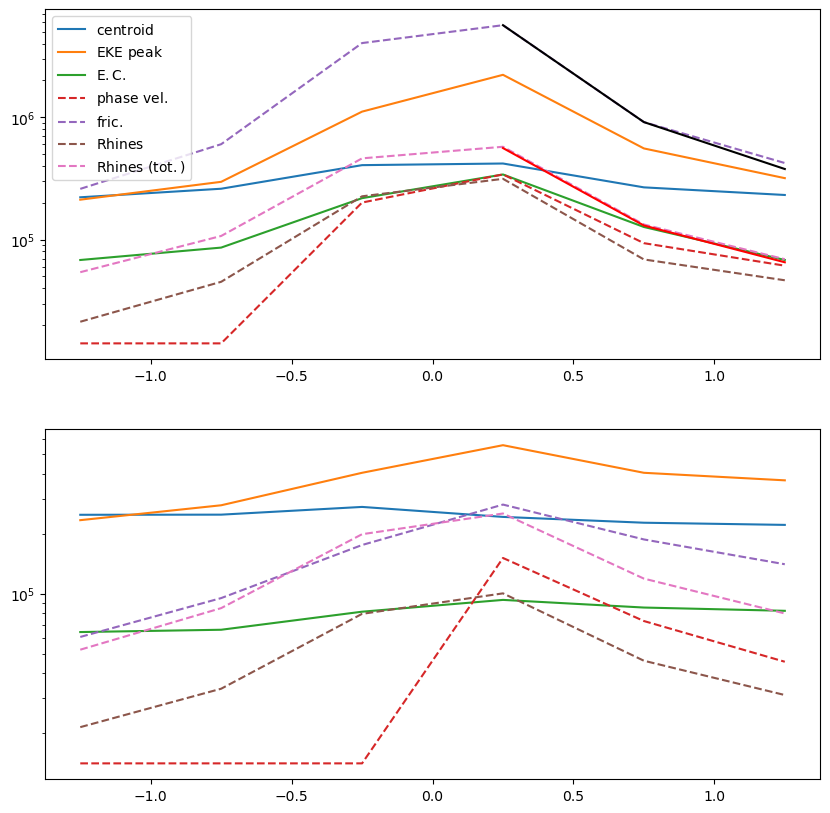

In [39]:
x = h0s[2:2:12] ./ S32

fig, ax = plt.subplots(2, 1, figsize=(10,10))


#######################################################################
### emergent scales
ax[1].plot(x, L_cent_mu0p25, label=L"\mathrm{centroid}", linestyle="solid")
ax[1].plot(x, L_peak_mu0p25, label=L"\mathrm{EKE \ peak}", linestyle="solid")
ax[1].plot(x, L_ec_mu0p25, label=L"\mathrm{E.C.}", linestyle="solid")


### diagnosed scales
ax[1].plot(x, L_wave_mu0p25, label=L"\mathrm{phase \ vel.}", linestyle="dashed")
ax[1].plot(x, utot_L_fric_mu0p25, label=L"\mathrm{fric.}", linestyle="dashed")
ax[1].plot(x, L_Rh_mu0p25, label=L"\mathrm{Rhines}", linestyle="dashed")
ax[1].plot(x, utot_L_Rh_mu0p25, label=L"\mathrm{Rhines \ (tot.)}", linestyle="dashed")

##
ax[1].plot(x[4:end], upert_L_Rh_mu0p25, "r-")
ax[1].plot(x[4:end], upert_L_fric_mu0p25, "k-")

#######################################################################
### emergent scales
ax[2].plot(x, L_cent_mu1p0, label=L"\mathrm{centroid}", linestyle="solid")
ax[2].plot(x, L_peak_mu1p0, label=L"\mathrm{EKE \ peak}", linestyle="solid")
ax[2].plot(x, L_ec_mu1p0, label=L"\mathrm{E.C.}", linestyle="solid")


### diagnosed scales
ax[2].plot(x, L_wave_mu1p0, label=L"\mathrm{phase \ vel.}", linestyle="dashed")
ax[2].plot(x, utot_L_fric_mu1p0, label=L"\mathrm{fric.}", linestyle="dashed")
ax[2].plot(x, L_Rh_mu1p0, label=L"\mathrm{Rhines}", linestyle="dashed")
ax[2].plot(x, utot_L_Rh_mu1p0, label=L"\mathrm{Rhines \ (tot.)}", linestyle="dashed")


#######################################################################
### 

ax[1].set_yscale("log")
ax[1].legend()


ax[2].set_yscale("log")


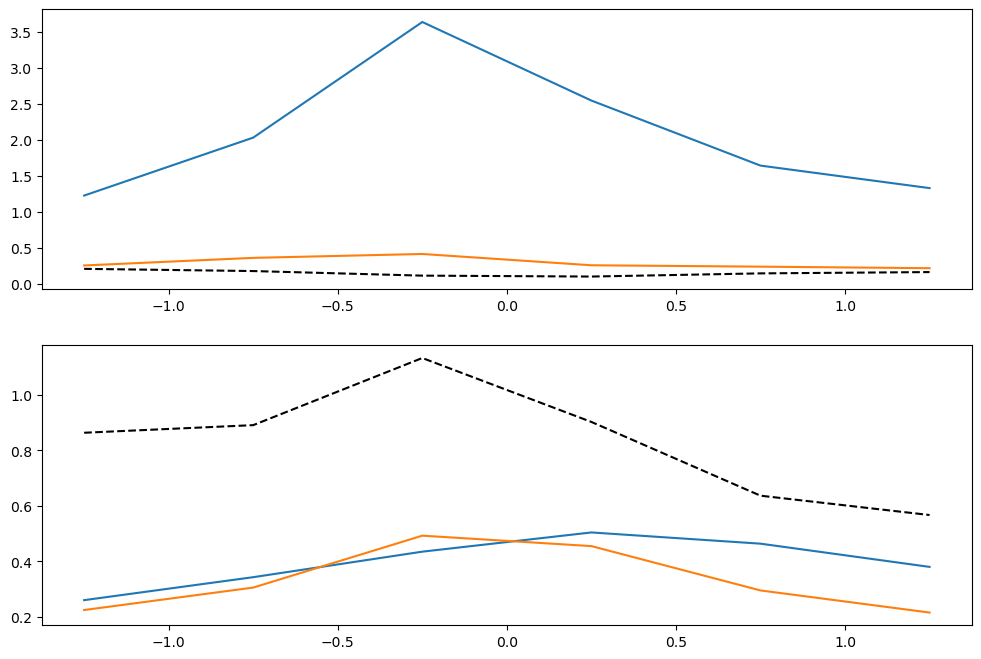

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x146d4c58dde0>

In [38]:
fig, ax = plt.subplots(2, 1, figsize=(12,8))

ax[1].plot(x, (utot_L_fric_mu0p25 ./ L_peak_mu0p25))
ax[1].plot(x, (utot_L_Rh_mu0p25 ./ L_peak_mu0p25))
ax[1].plot(x, utot_L_Rh_mu0p25 ./ utot_L_fric_mu0p25, "k--")



ax[2].plot(x, (utot_L_fric_mu1p0 ./ L_peak_mu1p0))
ax[2].plot(x, (utot_L_Rh_mu1p0 ./ L_peak_mu1p0))
ax[2].plot(x, utot_L_Rh_mu1p0 ./ utot_L_fric_mu1p0, "k--")



# plt.plot(L_wave_mu1p0)

# L_wave_mu1p0


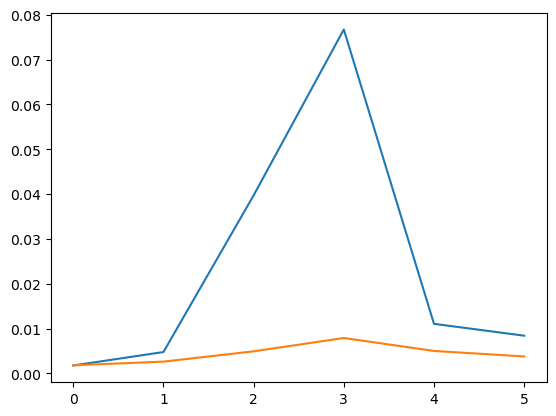

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x148d7009fdc0>

In [68]:
plt.plot(urms_mu0p25)
plt.plot(urms_mu1p0)

In [37]:

# analytical_str = "./c_of_k_m0p25_h0p25"
# diagnosed_str = "mu0p25_h0p25"
analytical_str = "./c_of_k_m1p0_hm1p25"
diagnosed_str = "mu1p0_hm1p25"
mu = mus[2]
h0 = h0s[2]

    aa = load(analytical_str*"_zonal.jld")
    da = load("./u_rms_"*diagnosed_str*".jld")

    urms = da["u_rms_" * diagnosed_str]["u_zonal_rms_" * diagnosed_str]

    kx = aa["dr_dict"]["kx"]

    nkx = length(kx)
    
    analytical_speed = zeros(nkx)
    
    for i in range(1,nkx)
        analytical_speed[i] = maximum(abs.([aa["dr_dict"]["c_of_k_BT"][i], aa["dr_dict"]["c_of_k_BC"][i]]))
    end

    sign_track = @. (urms - analytical_speed) / abs(urms .- analytical_speed)

    for i in range(1,nkx-1)
        sign_track[i] = sign_track[i]/sign_track[i+1]
    end

    beta_BT = f0 * h0 / H[2] / 2

    # these are: from phase speed, from friction, and Rhines scale
    wave_ind = findfirst(x -> x<0, sign_track)
    # if wave_ind==1
    #     wave_ind = findfirst(x -> x<0, sign_track[3:end])
    # end
    
    # return kx[wave_ind]^-1, kx[argmin(abs.((mu./kx) .- urms))]^-1, 2*pi*sqrt(urms/abs(beta_BT))


1000

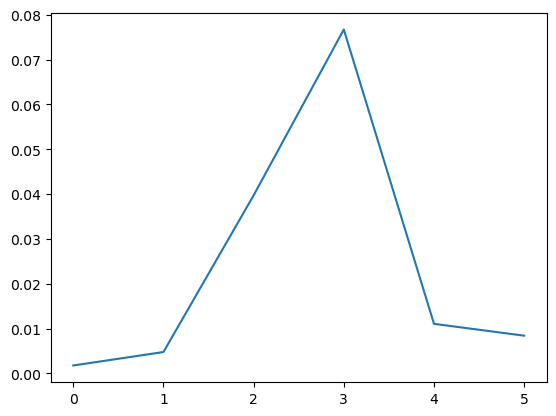

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x14b68e7d1f90>

In [25]:
# plt.plot(analytical_speed)
# plt.yscale("log")

# plt.plot(urms .- analytical_speed)
# plt.ylim(-0.01,0.01)

plt.plot(urms_mu0p25)

# Defining EKE timescale plots

In [19]:
using Roots

function dispersion_relation_full_bottom(beta_topo, U1, mode_string, mu_loc; kx=0, ky=0, frequency=false)

    # if ky==0

    #     k2 = 1 * (2 * pi / L)^2   # pre-factor of 2 assumes isotropic length scale; prefactor of 1 assumes zonal wavenumber only, l=0
        
    #     A = k2 * (k2 + Ld^-2)
    #     B = (beta_topo + im * mu_loc * sqrt(k2)) * (k2 + (2*Ld^2)^-1) - U1 * k2 * (k2 + Ld^-2)
    #     C = U1 * k2 * (U1 * (2 * Ld^2)^-1 - beta_topo - im * mu_loc * sqrt(k2))

    #     # a = @. k2 * (k2 + Ld^-2)
    #     # b = @. - U[1] * k2 * (k2 + Ld^-2) + (k2 + 0.5 * Ld^-2) * ((f0/H[2]) * h0 + 1im * μ * sqrt(k2))
    #     # c = @. - U[1] * k2 * ((f0/H[2]) * h0 - 0.5 * Ld^-2 *U[1] + 1im * μ * sqrt(k2)) 
        
    # else
    if kx==0
        
        k2 = ky^2   # pre-factor of 2 assumes isotropic length scale; prefactor of 1 assumes zonal wavenumber only, l=0
        
        A = k2 * (k2 + Ld^-2)
        # B = (beta_topo) * (k2 + (2*Ld^2)^-1) - U1 * k2 * (k2 + Ld^-2)
        # C = U1 * k2 * (U1 * (2 * Ld^2)^-1 - beta_topo)

        B = (im * mu_loc) * (k2 + (2*Ld^2)^-1)
        C = 0
        
        kx_to_k2 = 0.
    else
        k2 = kx^2 + ky^2   # pre-factor of 2 assumes isotropic length scale; prefactor of 1 assumes zonal wavenumber only, l=0
        
        A = k2 * (k2 + Ld^-2)
        B = (beta_topo + im * mu_loc * k2 / kx) * (k2 + (2*Ld^2)^-1) - U1 * k2 * (k2 + Ld^-2)
        C = U1 * k2 * (U1 * (2 * Ld^2)^-1 - beta_topo - im * mu_loc * k2/kx)

        kx_to_k2 = (kx/sqrt(k2))
    end
    
    # if mode_string=="BT"
    #     dr = U1/2 - (beta_topo / 2) / k2
    # elseif mode_string=="BC"
    #     dr = U1/2 - (beta_topo / 2) / (k2 + Ld^-2)
    # end

    # this is full dispersion relation for bottom slope PV gradient in lower layer only
    dr_both = [- B / 2 / A + real(sqrt(Complex(B^2 - 4 * A * C))) / 2 / A; - B / 2 / A - real(sqrt(Complex(B^2 - 4 * A * C))) / 2 / A]
    dr_both = dr_both .* kx_to_k2
    if mode_string=="BT"
        indmax = 1 # argmax(abs.(dr_both))
        dr = real(dr_both[indmax])
    elseif mode_string=="BC"
        indmin = 2 #argmin(abs.(dr_both))
        dr = real(dr_both[indmin])
    end

    # if real(B^2 - 4 * A * C) < 0
    #     println(B^2 - 4 * A * C)
    # end

    dr_both_comp = sqrt(k2) .* [- B / 2 / A + sqrt(Complex(B^2 - 4 * A * C)) / 2 / A; - B / 2 / A - sqrt(Complex(B^2 - 4 * A * C)) / 2 / A]
    dr_both_comp = dr_both_comp .* kx_to_k2
    
    disc = imag.(dr_both_comp)
    if any(abs.(disc) .> 0)
        max_growth = maximum((disc))
    else
        max_growth = 0.
    end

    # if (B^2 - 4 * A * C) > 0
    #     println(sqrt(B^2 - 4 * A * C) / B)
    # end
    # dr = U1/2 - beta_topo * (2*k2 + Ld^-2) / (2*k2 * (k2 + Ld^-2)) + sf * real(sqrt(Complex(U1^2 * k2^2 * (k2^2 - 2 * Ld^-2) + 2 * Ld^-2 * beta_topo^2)) / (2 * k2 * ( k2 + Ld^-2)))


    return dr, max_growth

end

############################################################################

############################################################################



dispersion_relation_full_bottom (generic function with 1 method)

In [20]:
dx = Lx/Nx
dy = Ly/Ny

kxp = collect(fftshift(fftfreq(Nx, 1/dx))) .* (2*pi*Ld)     # this is now radians (initially per meter), normed by Ld
kyp = reshape(collect(fftshift(fftfreq(Ny, 1/dy))) .* (2*pi*Ld), 1, Ny)     # this is now radians (initially per meter), normed by Ld



# ks = collect(range(0.001, 2, Nell)) ./ Ld
# kx_all = collect(range(1/(3*Ld), 1/(0.1*Ld), 200))
kx_all = kxp ./ (2*pi*Ld) #    this is now in cycles per meter
ky_all = kyp[:] ./ (2*pi*Ld) #    this is now in cycles per meter

ells_x = kx_all.^-1 # this is in meters (no radians; not normed by Ld)
ells_y = ky_all.^-1 # this is in meters (no radians; not normed by Ld))
# ells = collect(range(-30 * 2 * pi * Ld, 30 * 2 * pi * Ld, 200))  # kx_all.^-1 #

# Nell=201
# ells = collect(range(0, 100*2*pi*Ld, Nell-1))

# ells = [ells[2:end];Inf]


kvec_str = "iso"

mu_loc = mus[2]

c_BT_full = zeros(length(h0s), length(ells_x), length(ells_y))
c_BC_full = zeros(length(h0s), length(ells_x), length(ells_y))
growth = zeros(length(h0s), length(ells_x), length(ells_y))

for h_ind in [2, 4, 6, 8, 10, 12]  # range(1, length(h0s))

    h0 = (h0s[h_ind], 0.0)

    alpha_s = (f0 * h0s[h_ind] / H[2])

    for (i,Lkx) in enumerate(ells_x)
        for (j, Lky) in enumerate(ells_y)
            # if h_ind != 7
    
            # if kvec_str=="zonal"
            #     kx=2*pi/L0
            #     ky=0
            # elseif kvec_str=="ky_fixed"
            #     kx = 2*pi/L0
            #     ky = 2*pi/Lx*5
            # elseif kvec_str=="k_iso"
                global kx = 2*pi/Lkx    # this is in radians per meter
                global ky = 2*pi/Lky    # this is in radians per meter
            # end

            # these phase speeds are in m/s (no radians)
            c_BT_full[h_ind, i, j], nul = dispersion_relation_full_bottom(alpha_s, 0.01, "BT", 0.0; kx=kx, ky=ky) 
            c_BC_full[h_ind, i, j], nul = dispersion_relation_full_bottom(alpha_s, 0.01, "BC", 0.0; kx=kx, ky=ky)
            nul, growth[h_ind, i, j] = dispersion_relation_full_bottom(alpha_s, 0.01, "BC", mu_loc; kx=kx, ky=ky)
            
        end
    end
end




In [21]:
tau_wave = zeros(6, length(ells_x), length(ells_y))
tau_wave_BC = zeros(6, length(ells_x), length(ells_y))
tau_wave_BT = zeros(6, length(ells_x), length(ells_y))

h_ind_bank = [2, 4, 6, 8, 10, 12]

# ells_x, ells_y are in meters (no radians; not normed by Ld)
for (h, h_ind) in enumerate(h_ind_bank)
    for (i, lx) in enumerate(ells_x)
        for (j, ly) in enumerate(ells_y)
            l = sqrt(lx^-2 + ly^-2)^-1
            # tau_wave[h,i,j] = maximum(abs.([c_BC_full[h_ind, i, j], c_BT_full[h_ind, i, j]])) / l 

            # with c in m/s (no radians), this is a time scale in Hz (i.e., no radians)
            tau_wave_BT[h,i,j] = abs(c_BT_full[h_ind, i, j]) / l
            tau_wave_BC[h,i,j] = abs(c_BC_full[h_ind, i, j]) / l 
            tau_wave[h,i,j] = maximum(abs.([c_BC_full[h_ind, i, j], c_BT_full[h_ind, i, j]])) / l 
        end
    end
end


In [22]:

function EKE_timescale_d(i, k, kxp, kyp, data_dir)
    j=1  # quad drag index    
    
    h0 = (h0s[i], 0.0)
    kappa_loc = kappas[j]
    mu_loc = mus[k]
    
    global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, (0., 0.), h0, nus[i])
    global topo_PV, eta = define_topo(model_params)
    global model_params = redef_mu_kappa_topoPV_h0_nu(model_params, mu_loc, kappa_loc, topo_PV, h0, nus[i])
    
    global model_params = redef_mu_kappa_beta(model_params, mu_loc, kappa_loc, 0.)
    
    a = load(data_dir*jld_name(model_params,89.0))

    EKE_2D = reshape(sum(a["jld_data"]["kspace_modal_nrg_spectrum"], dims=3), Nx, Ny)
    
    tau_EKE = zeros(length(kxp), length(kyp))

    l_peak_EKE = zeros(length(kyp))

    fft_EKE = sqrt.(fftshift(EKE_2D))

    # kxp, kyp are in radians per meter times Ld (so, radians overall)
    for (i, kx) in enumerate(kxp ./ (2*pi*Ld))  # this correctly removes Ld and radian factors
        for (j, ky) in enumerate(kyp ./ (2*pi*Ld))
            l = sqrt(kx^2 + ky^2)^-1    # these are wavenumbers in inverse length (no radians)

            # factor of 2pi^2 req'd because grid.Ksq has factor of 2pi^2
            tau_EKE[i,j] = fft_EKE[i, j] / l / ((2*pi)^2)    # this is now in Hz, no normalization needed for radians, Ld, etc.
        end
    end

    for (j, ky) in enumerate(kyp ./ (2*pi*Ld))
        l_peak_EKE[j] = kxp[argmax(fft_EKE[:, j])] / (2 * pi * Ld)
        # l_peak_EKE[j] = sum(fft_EKE[513:end, j] .* (kxp[513:end] ./ (2 * pi * Ld))) / sum(fft_EKE[513:end, j])
    end 

    return tau_EKE, l_peak_EKE
end

data_dir_EKE_spec = "/scratch/cimes/ml1994/QG/julia/data/JPO_2LQG_on_slope_data/mu0p25_kspace/"


tau_EKE_mu0p25_hm1p25, l2peak_mu0p25_hm1p25 = EKE_timescale_d(2, 2, kxp, kyp, data_dir_EKE_spec);
tau_EKE_mu0p25_hm0p75, l2peak_mu0p25_hm0p75 = EKE_timescale_d(4, 2, kxp, kyp, data_dir_EKE_spec);
tau_EKE_mu0p25_hm0p25, l2peak_mu0p25_hm0p25 = EKE_timescale_d(6, 2, kxp, kyp, data_dir_EKE_spec);
tau_EKE_mu0p25_h0p25, l2peak_mu0p25_h0p25  = EKE_timescale_d(8, 2, kxp, kyp, data_dir_EKE_spec);
tau_EKE_mu0p25_h0p75, l2peak_mu0p25_h0p75  = EKE_timescale_d(10, 2, kxp, kyp, data_dir_EKE_spec);
tau_EKE_mu0p25_h1p25, l2peak_mu0p25_h1p25  = EKE_timescale_d(12, 2, kxp, kyp, data_dir_EKE_spec);





In [82]:
function plot_vlines(ax, vlines, lbl; clr="green", lst="dashed")

    ax1t = ax[1].twinx(); ax2t = ax[2].twinx(); ax3t = ax[3].twinx();
    ax4t = ax[4].twinx(); ax5t = ax[5].twinx(); ax6t = ax[6].twinx();
    
    ax6t.axvline(vlines[1], color=clr, linestyle=lst, label=lbl)
    ax4t.axvline(vlines[2], color=clr, linestyle=lst, label=lbl)
    ax2t.axvline(vlines[3], color=clr, linestyle=lst, label=lbl)
    
    ax5t.axvline(vlines[6], color=clr, linestyle=lst, label=lbl)
    ax3t.axvline(vlines[5], color=clr, linestyle=lst, label=lbl)
    ax1t.axvline(vlines[4], color=clr, linestyle=lst, label=lbl)

    ##
    ax6t.tick_params(axis="y", right=false, labelright=false)
    ax4t.tick_params(axis="y", right=false, labelright=false)
    ax2t.tick_params(axis="y", right=false, labelright=false)
    
    ax5t.tick_params(axis="y", right=false, labelright=false)
    ax3t.tick_params(axis="y", right=false, labelright=false)
    ax1t.tick_params(axis="y", right=false, labelright=false)

end


# L_cent_mu0p25
# L_peak_mu0p25
# L_ec_mu0p25 

# L_wave_mu0p25 
# L_fric_mu0p25
# L_Rh_mu0p25 

plot_vlines (generic function with 1 method)

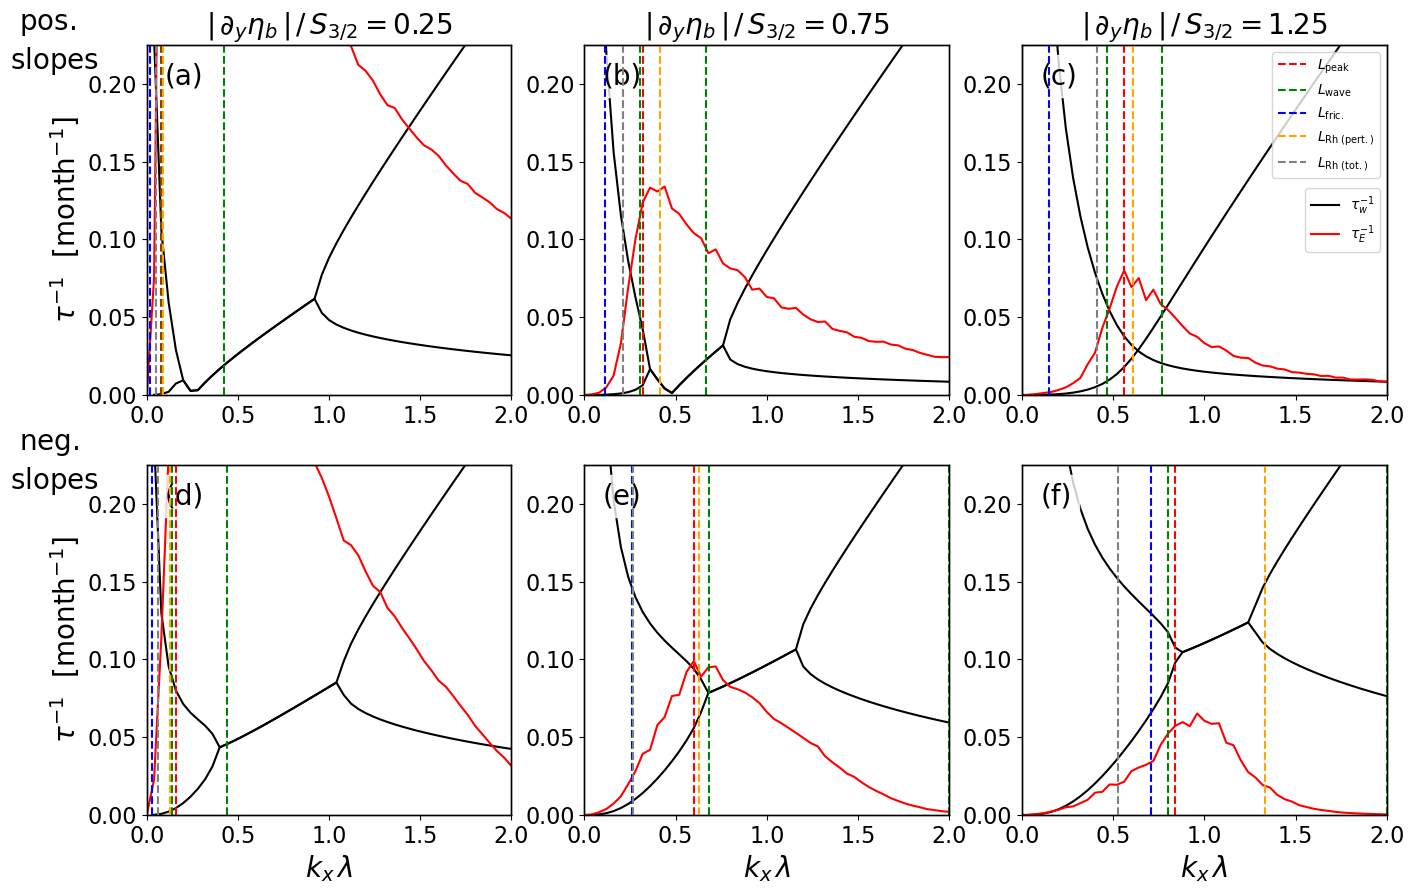

PyObject <matplotlib.legend.Legend object at 0x14c77bba0a00>

In [123]:
function plot_timescales(ax, tau_wave_BC, tau_wave_BT, tau_EKE, kxp)

    norm = 3600 * 24 * 31
    
    ax.plot(kxp, tau_wave_BC .* norm, "k-", label = L"\tau_{w}^{-1}")
    ax.plot(kxp, tau_wave_BT .* norm, "k-")
    
    ax.plot(kxp, tau_EKE .* norm, "r-", label = L"\tau_{E}^{-1}")
    
end

fsize = 20
lsize = 16

slice_ind = 513

fig, ax = plt.subplots(2,3, figsize=(16,10))

plot_timescales(ax[6], tau_wave_BC[1,:,slice_ind], tau_wave_BT[1,:,slice_ind], tau_EKE_mu0p25_hm1p25[:,slice_ind], kxp)
plot_timescales(ax[4], tau_wave_BC[2,:,slice_ind], tau_wave_BT[2,:,slice_ind], tau_EKE_mu0p25_hm0p75[:,slice_ind], kxp)
plot_timescales(ax[2], tau_wave_BC[3,:,slice_ind], tau_wave_BT[3,:,slice_ind], tau_EKE_mu0p25_hm0p25[:,slice_ind], kxp)

plot_timescales(ax[5], tau_wave_BC[6,:,slice_ind], tau_wave_BT[6,:,slice_ind], tau_EKE_mu0p25_h1p25[:,slice_ind], kxp)
plot_timescales(ax[3], tau_wave_BC[5,:,slice_ind], tau_wave_BT[5,:,slice_ind], tau_EKE_mu0p25_h0p75[:,slice_ind], kxp)
plot_timescales(ax[1], tau_wave_BC[4,:,slice_ind], tau_wave_BT[4,:,slice_ind], tau_EKE_mu0p25_h0p25[:,slice_ind], kxp)

# for (i, axn) in enumerate([ax[6], ax[4], ax[2], ax[1], ax[3], ax[5]])
#     axn.plot(kxp, urms_mu0p25[i] .* (3600*24*31) .* kxp ./(2*pi*Ld), color="red", linestyle="--", label=L"u_\mathrm{rms} k_{x}")
# end


clr = ["red", "green", "blue", "orange", "gray"]
lbl = [L"L_\mathrm{peak}", L"L_\mathrm{wave}", L"L_\mathrm{fric.}", L"L_\mathrm{Rh \ (pert.)}", L"L_\mathrm{Rh \ (tot.)}"]
ax5t = ax[5].twinx()
for l in range(1, length(lbl))
    ax5t.plot([NaN], [NaN], color=clr[l], label=lbl[l], linestyle="--")
end
ax5t.tick_params(axis="y", right=false, labelright=false)


plot_vlines(ax, ((Ld * 2*pi) ./ L_cent_mu0p25), L"L_\mathrm{cent.}"; clr="green")
plot_vlines(ax, (Ld * 2*pi) ./ L_peak_mu0p25, lbl[1]; clr=clr[1], lst="--")
# plot_vlines(ax, (Ld ) ./ L_ec_mu0p25, L"L_\mathrm{E.C.}"; clr="orange")


plot_vlines(ax, (Ld ./ L_wave_mu0p25), lbl[2]; clr=clr[2], lst="--")
plot_vlines(ax, (Ld ./ L_fric_mu0p25), lbl[3]; clr=clr[3], lst="--")
plot_vlines(ax, ((Ld)./ L_Rh_mu0p25), lbl[4]; clr=clr[4], lst="--")
plot_vlines(ax, ((Ld)./ utot_L_Rh_mu0p25), lbl[5]; clr=clr[5], lst="--")



for axn in ax
    axn.set_xlim(0.0,2)
    axn.set_ylim(0, 0.225)

    axn.tick_params(axis="both", labelsize=lsize) 

    # axn.set_yscale("log")
    # axn.set_xscale("log")

end

## labeling
ax[1].set_ylabel(L"\tau^{-1} \ \ [\mathrm{month}^{-1}]", fontsize=fsize)
ax[2].set_ylabel(L"\tau^{-1} \ \ [\mathrm{month}^{-1}]", fontsize=fsize)

ax[2].set_xlabel(L"k_{x} \, \lambda", fontsize=fsize)
ax[4].set_xlabel(L"k_{x} \, \lambda", fontsize=fsize)
ax[6].set_xlabel(L"k_{x} \, \lambda", fontsize=fsize)

ax[1].text(-0.35, 1.1, L"\mathrm{pos.}", transform=ax[1].transAxes, fontsize=fsize,
            ha="left", va="top")
ax[1].text(-0.375, 1.0, L"\mathrm{slopes}", transform=ax[1].transAxes, fontsize=fsize,
            ha="left", va="top")

ax[2].text(-0.35, 1.1, L"\mathrm{neg.}", transform=ax[2].transAxes, fontsize=fsize,
            ha="left", va="top")
ax[2].text(-0.375, 1.0, L"\mathrm{slopes}", transform=ax[2].transAxes, fontsize=fsize,
            ha="left", va="top")

ax[1].set_title(L"| \, \partial_{y} \eta_{b} \, | \, / \, S_{3/2} = 0.25", fontsize=fsize)
ax[3].set_title(L"| \, \partial_{y} \eta_{b} \, | \, / \, S_{3/2} = 0.75", fontsize=fsize)
ax[5].set_title(L"| \, \partial_{y} \eta_{b} \, | \, / \, S_{3/2} = 1.25", fontsize=fsize)

####
for (i,t) in enumerate(["(a)", "(d)", "(b)", "(e)", "(c)", "(f)"])
    ax[i].text(0.05, 0.95, t, transform=ax[i].transAxes, fontsize=fsize,
            ha="left", va="top", bbox=Dict(
        "facecolor"=>"white",  # Background color
        "alpha"=>0.8,          # Transparency (0=transparent, 1=opaque)
        "edgecolor"=>"white",  # Border color (set to match facecolor to avoid a visible edge)
        "pad"=>5.0             # Padding around the text
    ))
end

ax5t.legend()
ax[5].legend()
# savefig("./JPO_rev1_figs/timescale_kx.png",bbox_inches="tight")


# ax[1].set_xlim(0, 0.25)
# ax[2].set_xlim(0, 0.25)

# ax[1].set_ylim(0, 0.7)
# ax[2].set_ylim(0, 0.7)

In [126]:
mus[4]^-1/3600/24

65.56721332428235

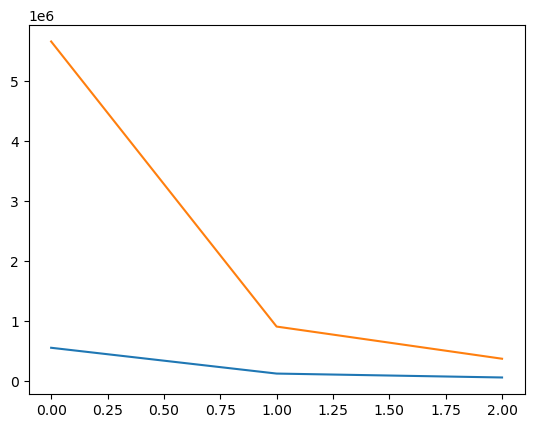

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x14717f8ca230>